# [분할 작업본 2/4] FFCell v80 (PART 번호 연속 정리판) — 모델링 초기 — 베이스라인 사다리 · 멘토/팀원 피드백 · Block A 재검증

- 범위: PART 5~9 (cell 133~253)
- 원본: `FFCell_integrated_notebook_v80_PART연속.ipynb` (PART 15~19 번호를 연속으로 재정리한 버전)

---


In [1]:
# ── [분할 파일 시작] 이전 파일(part4) 세션 복원 ─────────────────────────────
# 이 파일은 FFCell_integrated_notebook_v80(PART 번호 연속 정리판)을 작업용으로
# 4등분한 것 중 "모델링 초기" (PART 5~9) 부분이다. 아래 셀로 이전 파일 끝 시점
# 전체 상태를(함수·변수·df 전부) 그대로 복원한 뒤, 이어지는 셀부터 실행하면 된다.
from pathlib import Path
_CACHE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/FFCell/_checkpoints')

from google.colab import drive
drive.mount('/content/drive')

try:
    import dill
except ImportError:
    !pip install dill --quiet
    import dill

# [수정] 이전 파일에서 쓰던 패키지가 새 런타임엔 없어서 세션 복원이 실패하는 문제 방지
# (scikit_posthocs는 1of4에서만 설치했는데, 새 런타임에서 이 파일을 단독으로 열면 없음)
try:
    import scikit_posthocs
except ImportError:
    !pip install scikit-posthocs --quiet

try:
    import imblearn
except ImportError:
    !pip install imbalanced-learn --quiet

_session_path = _CACHE_DIR / 'part4_session.pkl'
if _session_path.exists():
    dill.load_session(str(_session_path))
    print(f"[세션 복원 완료] {_session_path} ← 이전 파일 상태를 그대로 이어받았습니다.")
else:
    print(f"[체크포인트 없음] {_session_path} 파일이 없습니다.")
    print("  → 이전 분할 파일을 먼저 끝까지 실행해서 체크포인트를 만들어두세요.")


Mounted at /content/drive
[세션 복원 완료] /content/drive/MyDrive/Colab Notebooks/FFCell/_checkpoints/part4_session.pkl ← 이전 파일 상태를 그대로 이어받았습니다.


In [2]:
# ── 한글 폰트 설정 (그래프 제목·범례 깨짐 방지) ──────────────────────────
# Colab은 새 런타임을 열 때마다 시스템 폰트가 초기화되므로, 파일을 열 때마다 다시 실행 필요.
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

import matplotlib as mpl
import matplotlib.font_manager as fm
fm.fontManager.__init__()
mpl.rc("font", family="NanumGothic")
mpl.rcParams["axes.unicode_minus"] = False
print("나눔고딕 설정 완료")


나눔고딕 설정 완료


---
# PART 5. 모델링 및 검증

RandomForest를 학습시키고, GroupKFold(세션 분리)·StratifiedKFold·세션 내부 시간순 검증까지 여러 각도로 재검증한 뒤 결론을 정리한다.
---

## 20. 모델링 — RandomForest (세션 단위 GroupKFold)

단일 GroupShuffleSplit 대신, 6개 세션을 전부 한 번씩 테스트로 사용하는 GroupKFold로
평균 성능과 세션별 편차를 함께 확인한다.

In [3]:
# ── RandomForest + GroupKFold(세션 단위) ────────────────────────────────
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model_df = final_features.dropna(subset=[c for c in final_features.columns if c != 'label'])
session_id = pd.Series(model_df.index, index=model_df.index).str.split('_').str[0]

feature_cols = [c for c in model_df.columns if c != 'label']
X = model_df[feature_cols]
y = model_df['label']
groups = session_id

print(f'모델 학습에 사용되는 사이클 수: {len(model_df)}개 (결측 제거 후)')
print(f'(참고) window_shape_features 수정 전 기존 기준선: 266개 — 위 숫자와 비교할 것')
print(f'세션별 사이클 수:\n{groups.value_counts().sort_index()}')

gkf = GroupKFold(n_splits=groups.nunique())
fold_accuracies = []
all_y_true, all_y_pred = [], []

for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(acc)
    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())
    print(f'Fold {fold_i} (세션 {groups.iloc[test_idx].iloc[0]}): 정확도 {acc:.3f}, n={len(test_idx)}')

print(f'\n[GroupKFold OOF 요약] 평균 정확도: {np.mean(fold_accuracies):.3f}  |  '
      f'표준편차: {np.std(fold_accuracies):.3f}')

print('\n[전체 OOF 분류 리포트]')
print(classification_report(all_y_true, all_y_pred, zero_division=0))

labels_present = sorted(set(all_y_true) | set(all_y_pred))
print('[전체 OOF 혼동행렬]')
print(pd.DataFrame(confusion_matrix(all_y_true, all_y_pred, labels=labels_present),
                    index=labels_present, columns=labels_present))

# 마지막 fold 모델 기준 피처 중요도 (참고용)
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print('\n[피처 중요도 Top 10] (마지막 fold 모델 기준)')
print(importances.head(10).round(4))


모델 학습에 사용되는 사이클 수: 320개 (결측 제거 후)
(참고) window_shape_features 수정 전 기존 기준선: 266개 — 위 숫자와 비교할 것
세션별 사이클 수:
cycle_id
1      4
2     15
3     11
4     15
5    275
Name: count, dtype: int64
Fold 0 (세션 5): 정확도 0.116, n=275
Fold 1 (세션 4): 정확도 1.000, n=15
Fold 2 (세션 2): 정확도 1.000, n=15
Fold 3 (세션 3): 정확도 1.000, n=11
Fold 4 (세션 1): 정확도 1.000, n=4

[GroupKFold OOF 요약] 평균 정확도: 0.823  |  표준편차: 0.353

[전체 OOF 분류 리포트]
                        precision    recall  f1-score   support

                NoNose       0.20      1.00      0.33        59
        NoNose,NoBody2       0.00      0.00      0.00        51
NoNose,NoBody2,NoBody1       0.00      0.00      0.00        54
                Normal       1.00      0.12      0.21       156

              accuracy                           0.24       320
             macro avg       0.30      0.28      0.13       320
          weighted avg       0.52      0.24      0.16       320

[전체 OOF 혼동행렬]
                        NoNose  NoNose,NoBody2  NoNose,NoBody2,N

## 21. 모델 성능 재검증 — 세션별 라벨 편중 및 정보 누수(leakage) 점검

섹션 20의 GroupKFold 결과에서 표본이 적은 세션(1·2·3·4)이 정확도 0.93~1.00을 보인 것은
실력이 아니라 **우연 또는 정보 누수**일 가능성이 제기됐다. 특히 피처 중요도 상위 10위
안에 있던 `Q_Cell_CycleCount_mean`은 '몇 번째 사이클인지'를 나타내는 값으로, 세션
식별 정보와 사실상 동일하다 — 그리고 이 프로젝트 초반에 이미 **결함 라벨이 6개의
큰 연속 시간 블록으로 몰려 수집됐다**는 사실이 확인된 바 있다. 즉 '세션이 곧 라벨을
암시하는' 상황일 수 있다는 뜻이다.

이번 섹션은 이 의심을 두 단계로 직접 검증한다.

1. **세션별 라벨 구성 확인** — 표본이 적은 세션들이 단일 클래스로만 구성되어 있는지 확인
2. **시간/순번 누수 피처 제거 후 재학습** — `Q_Cell_CycleCount_*` 등 세션을 암시하는
   피처를 제거하고 GroupKFold를 재실행해, 정확도가 실제로 하락하는지 확인

In [4]:
# ── [신규 21-1] 세션별 라벨 구성 확인 — 작은 세션들이 단일 클래스인가? ────────────
session_label_dist = pd.crosstab(session_id, y)
print('[세션별 라벨 구성] (행=세션, 열=클래스, 값=사이클 수)')
print(session_label_dist)

print('\n[세션별 최다 클래스 비율] (1.0에 가까울수록 사실상 단일 클래스)')
dominant_ratio = session_label_dist.div(session_label_dist.sum(axis=1), axis=0).max(axis=1)
print(dominant_ratio.round(3))

for sess in dominant_ratio.index:
    n = session_label_dist.loc[sess].sum()
    ratio = dominant_ratio.loc[sess]
    flag = ' ← 사실상 단일 클래스 (의심)' if ratio >= 0.9 else ''
    print(f'  세션 {sess}: n={n}, 최다 클래스 비율={ratio:.1%}{flag}')

print('\n※ GroupKFold에서 정확도 0.93~1.00이 나왔던 세션(1,2,3,4)이 여기서')
print('  단일 클래스에 가깝다면, "실력"이 아니라 "우연히 쉬운 시험"이었을 가능성이 크다.')


[세션별 라벨 구성] (행=세션, 열=클래스, 값=사이클 수)
label     NoNose  NoNose,NoBody2  NoNose,NoBody2,NoBody1  Normal
cycle_id                                                        
1              0               0                       0       4
2              1               0                       0      14
3             11               0                       0       0
4             15               0                       0       0
5             32              51                      54     138

[세션별 최다 클래스 비율] (1.0에 가까울수록 사실상 단일 클래스)
cycle_id
1    1.000
2    0.933
3    1.000
4    1.000
5    0.502
dtype: float64
  세션 1: n=4, 최다 클래스 비율=100.0% ← 사실상 단일 클래스 (의심)
  세션 2: n=15, 최다 클래스 비율=93.3% ← 사실상 단일 클래스 (의심)
  세션 3: n=11, 최다 클래스 비율=100.0% ← 사실상 단일 클래스 (의심)
  세션 4: n=15, 최다 클래스 비율=100.0% ← 사실상 단일 클래스 (의심)
  세션 5: n=275, 최다 클래스 비율=50.2%

※ GroupKFold에서 정확도 0.93~1.00이 나왔던 세션(1,2,3,4)이 여기서
  단일 클래스에 가깝다면, "실력"이 아니라 "우연히 쉬운 시험"이었을 가능성이 크다.


### 21-2. 시간/순번 누수 피처 제거 후 재검증

`Q_Cell_CycleCount_*`처럼 '몇 번째 사이클인지'를 직접 담은 피처, 그리고 세션 식별과
강하게 얽혀있을 수 있는 시간 관련 통계 피처를 제거한 뒤 GroupKFold를 다시 실행한다.
제거 후 정확도가 크게 떨어지면, 기존 모델이 실제 결함 신호가 아니라 '이 사이클이
몇 번째였는지'를 외워서 맞혔다는 것이 확인되는 것이다.

In [5]:
# ── [신규 21-2] 누수 의심 피처 제거 후 GroupKFold 재실행 ────────────────────
leak_suspect_cols = [c for c in feature_cols if 'CycleCount' in c or 'cycle_count' in c.lower()]
print(f'제거 대상(누수 의심) 피처: {leak_suspect_cols}')

feature_cols_clean = [c for c in feature_cols if c not in leak_suspect_cols]
X_clean = model_df[feature_cols_clean]

fold_accuracies_clean = []
all_y_true_clean, all_y_pred_clean = [], []

for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X_clean, y, groups=groups)):
    X_train, X_test = X_clean.iloc[train_idx], X_clean.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    clf_clean = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
    clf_clean.fit(X_train, y_train)
    y_pred = clf_clean.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    fold_accuracies_clean.append(acc)
    all_y_true_clean.extend(y_test.tolist())
    all_y_pred_clean.extend(y_pred.tolist())
    print(f'Fold {fold_i} (세션 {groups.iloc[test_idx].iloc[0]}): 정확도 {acc:.3f}, n={len(test_idx)}')

print(f'\n[누수 피처 제거 후] 평균 정확도: {np.mean(fold_accuracies_clean):.3f}  |  '
      f'표준편차: {np.std(fold_accuracies_clean):.3f}')

print('\n[비교] 제거 전 vs 제거 후 Fold별 정확도')
compare_fold = pd.DataFrame({
    'session': [groups.iloc[te].iloc[0] for _, te in gkf.split(X, y, groups=groups)],
    'acc_before': fold_accuracies,
    'acc_after': fold_accuracies_clean,
})
compare_fold['diff'] = compare_fold['acc_after'] - compare_fold['acc_before']
print(compare_fold)

print('\n[누수 제거 후 전체 OOF 분류 리포트]')
print(classification_report(all_y_true_clean, all_y_pred_clean, zero_division=0))

print('※ 표본이 적었던 세션(특히 단일 클래스에 가까웠던 세션)에서 정확도가 크게')
print('  떨어진다면, 기존 100% 정확도가 정보 누수 때문이었다는 것이 확인된 것이다.')
print('  큰 세션(세션5)의 정확도가 여전히 낮다면, 그건 누수와 무관한 별개의 문제')
print('  (진짜 일반화 실패)로 봐야 한다.')


제거 대상(누수 의심) 피처: ['Q_Cell_CycleCount_mean', 'Q_Cell_CycleCount_min', 'Q_Cell_CycleCount_max']
Fold 0 (세션 5): 정확도 0.116, n=275
Fold 1 (세션 4): 정확도 1.000, n=15
Fold 2 (세션 2): 정확도 1.000, n=15
Fold 3 (세션 3): 정확도 1.000, n=11
Fold 4 (세션 1): 정확도 1.000, n=4

[누수 피처 제거 후] 평균 정확도: 0.823  |  표준편차: 0.353

[비교] 제거 전 vs 제거 후 Fold별 정확도
  session  acc_before  acc_after  diff
0       5    0.116364   0.116364   0.0
1       4    1.000000   1.000000   0.0
2       2    1.000000   1.000000   0.0
3       3    1.000000   1.000000   0.0
4       1    1.000000   1.000000   0.0

[누수 제거 후 전체 OOF 분류 리포트]
                        precision    recall  f1-score   support

                NoNose       0.20      1.00      0.33        59
        NoNose,NoBody2       0.00      0.00      0.00        51
NoNose,NoBody2,NoBody1       0.00      0.00      0.00        54
                Normal       1.00      0.12      0.21       156

              accuracy                           0.24       320
             macro avg       0.30

### 정리 (섹션 21)

세션1~4가 사실상 단일 클래스(93~100%)였고, 누수 의심 피처(`Q_Cell_CycleCount_*`) 제거 후에도 결론은 바뀌지 않았다 — **세션5(전체의 85%, 4클래스 모두 포함) 자체의 OOF 정확도가 0.117로 매우 낮다**는 것이 핵심 발견이다. 전체 종합 해석은 맨 뒤 결론(섹션 24)에서 섹션 22와 함께 다룬다.


## 22. Stratified K-Fold — 클래스 균형 재검증

섹션 21에서 확인된 문제: `NoNose,NoBody2`와 `NoNose,NoBody2,NoBody1` 클래스가 세션5에만
존재해, GroupKFold로 세션을 분리하면 학습 데이터가 이 두 클래스를 한 번도 보지 못한다.
이는 '세션(시간대)이 바뀌어도 잘 맞히는가'라는 질문에는 유효한 검증이지만, '네 클래스를
애초에 구분할 능력이 있는가'라는 더 급한 질문에는 답을 주지 못한다.

**StratifiedKFold**는 세션 경계를 무시하고, 각 fold에 4개 클래스가 원본 비율대로
고르게 섞여 들어가도록 나눈다. 세션 정보 누수 가능성은 있으므로(같은 세션의 사이클이
train/test에 함께 들어갈 수 있음), 이 결과는 '순수 분류 능력의 상한선'으로 해석하고,
섹션 20(GroupKFold, 세션 일반화)과 반드시 함께 봐야 한다.


In [6]:
# ── StratifiedKFold — 클래스 비율을 고르게 섞어서 재검증 ──────────────────────
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_acc_strat = []
all_y_true_strat, all_y_pred_strat = [], []

for fold_i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    clf_s = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
    clf_s.fit(X_train, y_train)
    y_pred = clf_s.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    fold_acc_strat.append(acc)
    all_y_true_strat.extend(y_test.tolist())
    all_y_pred_strat.extend(y_pred.tolist())
    print(f'Fold {fold_i}: 정확도 {acc:.3f}, n={len(test_idx)}  '
          f'(클래스 구성: {y_test.value_counts().to_dict()})')

print(f'\n[StratifiedKFold OOF 요약] 평균 정확도: {np.mean(fold_acc_strat):.3f}  |  '
      f'표준편차: {np.std(fold_acc_strat):.3f}')

print('\n[StratifiedKFold 전체 OOF 분류 리포트]')
print(classification_report(all_y_true_strat, all_y_pred_strat, zero_division=0))

labels_present_s = sorted(set(all_y_true_strat) | set(all_y_pred_strat))
print('[StratifiedKFold 전체 OOF 혼동행렬]')
print(pd.DataFrame(confusion_matrix(all_y_true_strat, all_y_pred_strat, labels=labels_present_s),
                    index=labels_present_s, columns=labels_present_s))

importances_s = pd.Series(clf_s.feature_importances_, index=feature_cols).sort_values(ascending=False)
print('\n[피처 중요도 Top 10] (마지막 fold 모델 기준)')
print(importances_s.head(10).round(4))

print('\n[GroupKFold vs StratifiedKFold 비교]')
print(f'  GroupKFold(세션 일반화)     평균 정확도: {np.mean(fold_accuracies):.3f}')
print(f'  StratifiedKFold(클래스 균형) 평균 정확도: {np.mean(fold_acc_strat):.3f}')
print('※ 두 값의 차이가 크면, 지금 모델은 "클래스는 구분할 줄 알지만 새로운 시간대(세션)로')
print('  가면 무너진다"는 뜻 — 즉 세션 간 일반화가 남은 과제임을 재확인하는 결과다.')


Fold 0: 정확도 1.000, n=64  (클래스 구성: {'Normal': 32, 'NoNose': 11, 'NoNose,NoBody2': 11, 'NoNose,NoBody2,NoBody1': 10})
Fold 1: 정확도 0.984, n=64  (클래스 구성: {'Normal': 31, 'NoNose': 12, 'NoNose,NoBody2,NoBody1': 11, 'NoNose,NoBody2': 10})
Fold 2: 정확도 1.000, n=64  (클래스 구성: {'Normal': 31, 'NoNose': 12, 'NoNose,NoBody2,NoBody1': 11, 'NoNose,NoBody2': 10})
Fold 3: 정확도 0.953, n=64  (클래스 구성: {'Normal': 31, 'NoNose': 12, 'NoNose,NoBody2,NoBody1': 11, 'NoNose,NoBody2': 10})
Fold 4: 정확도 0.969, n=64  (클래스 구성: {'Normal': 31, 'NoNose': 12, 'NoNose,NoBody2,NoBody1': 11, 'NoNose,NoBody2': 10})

[StratifiedKFold OOF 요약] 평균 정확도: 0.981  |  표준편차: 0.018

[StratifiedKFold 전체 OOF 분류 리포트]
                        precision    recall  f1-score   support

                NoNose       0.96      0.93      0.95        59
        NoNose,NoBody2       1.00      0.98      0.99        51
NoNose,NoBody2,NoBody1       1.00      1.00      1.00        54
                Normal       0.97      0.99      0.98       156

         

### 정리 (섹션 22)

StratifiedKFold OOF 정확도는 **0.978**로 매우 높다 — 즉 네 클래스를 가르는 신호(R03 nose 피처 등)는 충분히 강력하다. 문제는 피처가 아니라 **세션 간 일반화**(섹션 21)에 있다는 뜻이다. 두 지표를 함께 놓고 보는 종합 해석은 맨 뒤 결론(섹션 24)에서 정리한다.


### 22-1. 세션5 내부 KFold 검증 (멘토 피드백 반영)

멘토님 피드백: "세션5 내부에서 KFold를 돌려봐라." 그런데 그냥 랜덤 셔플로 KFold를 돌리면
바로 옆 시간대 사이클들이 train/test에 함께 섞여 들어가, StratifiedKFold(전체)에서 이미
봤던 것과 같은 착시(0.978)가 재현될 위험이 있다. 그래서 **① 멘토님이 말씀하신 그대로의
KFold**와, **② 시간순으로 진짜 안 보이는 미래를 예측하는지 보는 검증**을 같이 돌려서 비교한다.


In [7]:
# ── 세션5 내부 라벨 블록 구조 확인 ──────────────────────────────────────
s5_mask = (session_id == '5')
X_s5, y_s5 = X[s5_mask], y[s5_mask]

# 시간순 정렬 (cycle_id 뒷숫자는 이미 시간순으로 매겨져 있음 — 14장에서 확인된 규칙)
order = sorted(X_s5.index, key=lambda c: int(c.split('_')[1]))
X_s5, y_s5 = X_s5.loc[order], y_s5.loc[order]

block_id = y_s5.ne(y_s5.shift()).cumsum()
print('[세션5 내부 라벨 블록 구조]')
for b in block_id.unique():
    members = block_id[block_id == b].index
    print(f'  블록{b}: 라벨={y_s5[members[0]]:28s} 개수={len(members)}')

[세션5 내부 라벨 블록 구조]
  블록1: 라벨=NoNose                       개수=9
  블록2: 라벨=NoNose,NoBody2               개수=51
  블록3: 라벨=NoNose,NoBody2,NoBody1       개수=54
  블록4: 라벨=Normal                       개수=138
  블록5: 라벨=NoNose                       개수=23


In [8]:
# ── ① 멘토님 지시 그대로: 세션5 내부에서 일반 StratifiedKFold ──────────────────
skf_s5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_plain = []
for tr, te in skf_s5.split(X_s5, y_s5):
    clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
    clf.fit(X_s5.iloc[tr], y_s5.iloc[tr])
    acc_plain.append(clf.score(X_s5.iloc[te], y_s5.iloc[te]))
print(f'[① 세션5 내부, 일반 KFold(랜덤 셔플)] 평균 정확도: {np.mean(acc_plain):.3f} (±{np.std(acc_plain):.3f})')

[① 세션5 내부, 일반 KFold(랜덤 셔플)] 평균 정확도: 0.985 (±0.014)


**⚠️ 주의 — 블록 그대로 leave-one-out 하면 안 되는 이유**: 위 블록 구조를 보면 블록2·3·4는
각각 `NoNose,NoBody2` / `NoNose,NoBody2,NoBody1` / `Normal`이 세션5에서 **딱 한 번만**
등장한다. 이 블록을 통째로 테스트로 빼면 학습 데이터에 그 클래스가 아예 없어서, "시간이
지나도 잘 맞히는지"가 아니라 "본 적도 없는 클래스를 맞혀봐"라는 불가능한 시험이 된다
(실제로 시도하면 그 블록들 정확도가 0.000으로 나온다). **`NoNose`만 블록1·블록5에 두 번
등장**하므로, 이 클래스에 대해서만 "초반에 배워서 후반을 맞히는지"를 공정하게 검증할 수 있다.


In [9]:
# ── ② 진짜 시간 드리프트 검증: NoNose를 초반(블록1)에서 배워 후반(블록5)에서 테스트 ──────
y_bin = (y_s5 == 'NoNose').astype(int)
late_nonose_idx = y_s5[block_id == block_id.max()].index  # 마지막 블록(=후반 NoNose)

train_mask = ~X_s5.index.isin(late_nonose_idx)
clf2 = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
clf2.fit(X_s5[train_mask], y_bin[train_mask])
acc_late = clf2.score(X_s5.loc[late_nonose_idx], y_bin.loc[late_nonose_idx])
print(f'[② NoNose 초반→후반 일반화] 후반 NoNose {len(late_nonose_idx)}개 대상 정확도: {acc_late:.3f}')
print('\n※ ①과 ②의 차이가 크면, ①의 높은 정확도는 "같은 시간대끼리 섞인" 착시라는 뜻이다.')

[② NoNose 초반→후반 일반화] 후반 NoNose 23개 대상 정확도: 0.000

※ ①과 ②의 차이가 크면, ①의 높은 정확도는 "같은 시간대끼리 섞인" 착시라는 뜻이다.


In [10]:
# ── 모델이 후반 NoNose 23개를 '어떻게' 틀리는지 진단 ──────────────────────────
preds = clf2.predict(X_s5.loc[late_nonose_idx])
probs = clf2.predict_proba(X_s5.loc[late_nonose_idx])[:, 1]
print('예측값 분포:', pd.Series(preds).value_counts().to_dict())
print(f'평균 예측 확률(NoNose일 확률): {probs.mean():.3f}')
print(f'확률 범위: {probs.min():.3f} ~ {probs.max():.3f}')

예측값 분포: {0: 23}
평균 예측 확률(NoNose일 확률): 0.010
확률 범위: 0.000 ~ 0.013


**진단 해석**: 예측이 전부 0(NoNose 아님)이고 확률도 낮게(0.1~0.3대) 나오면 모델이 "확신을
갖고 틀리는" 상태다. 확률이 애매하게(0.4~0.5 근처) 나온다면, 초반 NoNose가 **9개뿐**이라
데이터가 부족해서 생긴 "잘 모르겠다"에 가깝다 — 이 경우 피처를 더 고치는 것보다 **해당
클래스의 데이터를 더 모으는 쪽이 우선**이다.

**해석 가이드**

| 결과 패턴 | 의미 |
|---|---|
| ① 높음 & ② 도 높음 | 세션5 안에서는 시간이 지나도 잘 버틴다 — 좋은 신호 |
| ① 높음 & ② 낮음 | ①은 착시 — 실제로는 새 시간대로 갈 때마다 잘 못 맞힘 |
| ① 도 낮음 | 세션5 데이터로도 학습이 잘 안 됨 — 피처 보강이 우선 |

(참고: 최종 피처셋 대신 R03 nose 신호 2개짜리 간이 피처로 미리 돌려보니 ①=0.924,
②=0.565가 나왔다 — ①·② 차이가 크다는 뜻으로, 실제 124개 피처로 재실행하면 이 격차가
어떻게 바뀌는지 확인이 필요하다.)

### 22-2. VFD 온도 시계열 누수 점검 (신규)

피처 124개를 전부 분류해보니 `Q_Cell_CycleCount_*`(3개, 이미 확인된 누수 의심) 외에
**`Q_VFD1~4_Temperature_*` 14개**가 새로운 누수 후보로 나왔다. VFD(가변주파수구동기)는
오래 켜져 있을수록 온도가 오르는 게 당연하므로, "사이클이 세션 초반/후반인지"를 그대로
반영할 수 있다. 먼저 실제로 시간(순번)과 상관관계가 있는지 확인하고, 있다면 이 피처들까지
제거한 뒤 22-1의 "② NoNose 초반→후반 일반화" 테스트를 다시 돌려본다.

In [11]:
# ── VFD 온도가 세션5 내 시간순번과 상관관계가 있는지 확인 ──────────────────────
cycle_order = pd.Series(range(len(X_s5)), index=X_s5.index)  # 세션5 내 시간순 순번(0=가장 이른 사이클)
vfd_cols = [c for c in X_s5.columns if 'VFD' in c]
print(f'VFD 온도 피처 {len(vfd_cols)}개 × 세션5 내 시간순번 상관계수')
for col in vfd_cols:
    r = np.corrcoef(cycle_order, X_s5[col])[0, 1]
    flag = '  <-- 시간과 상관 강함' if abs(r) > 0.5 else ''
    print(f'  {col:28s}: r={r:+.3f}{flag}')

VFD 온도 피처 14개 × 세션5 내 시간순번 상관계수
  Q_VFD2_Temperature_max      : r=+0.075
  Q_VFD2_Temperature_mean     : r=+0.120
  Q_VFD4_Temperature_max      : r=+0.254
  Q_VFD4_Temperature_mean     : r=+0.258
  Q_VFD1_Temperature_mean     : r=+0.262
  Q_VFD3_Temperature_mean     : r=+0.251
  Q_VFD1_Temperature_max      : r=+0.266
  Q_VFD4_Temperature_min      : r=-0.110
  Q_VFD2_Temperature_min      : r=+0.048
  Q_VFD3_Temperature_max      : r=+0.250
  Q_VFD1_Temperature_min      : r=+0.272
  Q_VFD3_Temperature_min      : r=+0.032
  Q_VFD4_Temperature_std      : r=+0.071
  Q_VFD1_Temperature_std      : r=-0.202


**해석 가이드**: |r| > 0.5 정도로 나오는 피처가 많으면, VFD 온도가 실제로 "몇 시인지"를
대신 알려주는 시계열 누수 피처라는 뜻이다. 절댓값이 낮으면(예: |r|<0.2) 온도가 순번과
무관하게 유지된 것이므로 이 피처들은 계속 써도 된다.

In [12]:
# ── Q_Cell_CycleCount_* + Q_VFD*_Temperature_* 를 함께 제거하고 22-1 ②를 재실행 ──────
leak_cols_v2 = [c for c in X_s5.columns if 'CycleCount' in c or 'VFD' in c]
print(f'제거 대상 피처 {len(leak_cols_v2)}개: {leak_cols_v2}')

X_s5_clean = X_s5.drop(columns=leak_cols_v2)

clf3 = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
clf3.fit(X_s5_clean[train_mask], y_bin[train_mask])
acc_late_clean = clf3.score(X_s5_clean.loc[late_nonose_idx], y_bin.loc[late_nonose_idx])

print(f'\n[제거 전] 후반 NoNose 23개 정확도: {acc_late:.3f}')
print(f'[CycleCount+VFD 17개 제거 후] 후반 NoNose 23개 정확도: {acc_late_clean:.3f}')

제거 대상 피처 17개: ['Q_Cell_CycleCount_mean', 'Q_Cell_CycleCount_min', 'Q_Cell_CycleCount_max', 'Q_VFD2_Temperature_max', 'Q_VFD2_Temperature_mean', 'Q_VFD4_Temperature_max', 'Q_VFD4_Temperature_mean', 'Q_VFD1_Temperature_mean', 'Q_VFD3_Temperature_mean', 'Q_VFD1_Temperature_max', 'Q_VFD4_Temperature_min', 'Q_VFD2_Temperature_min', 'Q_VFD3_Temperature_max', 'Q_VFD1_Temperature_min', 'Q_VFD3_Temperature_min', 'Q_VFD4_Temperature_std', 'Q_VFD1_Temperature_std']

[제거 전] 후반 NoNose 23개 정확도: 0.000
[CycleCount+VFD 17개 제거 후] 후반 NoNose 23개 정확도: 0.000


**해석 가이드**

| 결과 | 의미 |
|---|---|
| 제거 후에도 0.000 근처 | 진짜 시간 드리프트 문제 — 피처 탓이 아니라 근본적인 일반화 실패. 세션5 데이터를 더 모으거나 도메인 적응 검토 |
| 제거 후 크게 상승(0.5 이상) | `CycleCount`·`VFD` 온도가 주범이었음 — **이 17개 피처를 최종 모델에서 영구 제외**하는 것만으로 상당 부분 해결 가능 |
| 그 사이 애매하게 상승 | 두 원인이 섞여 있음 — 남은 피처 중에서도 세션/시간과 상관된 것이 더 있는지 추가 점검 필요 (예: `r04_Body2_제거_*`, `r04_Body1_제거_*`) |


## 23. 사이클 수 통일 + Normal 손실 원인 진단 (멘토 피드백 마무리)

오늘 멘토링에서 남은 두 가지를 코드로 마무리한다.

1. **사이클 수 통일**: 파이프라인 전체에 흩어진 325→323→320→266이라는 4개 숫자를
   한 곳에 모아 "깔때기(funnel)" 형태로 정리하고, 각 단계에서 왜 몇 개가 빠졌는지
   명확히 기록한다.
2. **Normal 162→106 원인 진단**: 어떤 피처(컬럼)의 결측이 Normal 사이클을 유독
   많이 떨어뜨리는지 컬럼 단위로 분해해서 확인한다.


### 23-1. 사이클 수 깔때기 (한 곳에서 통일)


In [13]:
# ── 사이클 수 통일 — 전체 파이프라인 단계별 하나의 표로 정리 ──────────────────
cycle_funnel = []

cycle_funnel.append(('① 원본 스펙 (reset_flag 경계 온전)', 325,
                     '지속시간 기준 불완전 사이클 2개(2_0, 4_0) 제거 후'))
cycle_funnel.append(('② 센서 QA (R01·R04 워밍업 제외)', 323,
                     "1_1, 1_2 (R04 부하 변동성 이상 — 14장 v80 정정) 추가 제외"))
cycle_funnel.append(('③ 최종 피처셋 (세션0 제외)', len(final_features),
                     "'0_' 프리픽스 세션0(워밍업, 3개) 제외"))
cycle_funnel.append(('④ 모델 학습 (전체 피처 dropna)', len(model_df),
                     '124개 피처 중 하나라도 NaN이면 사이클 전체 제외'))

print('[사이클 수 깔때기 — 단계별 통일 기록]')
prev = None
for name, n, reason in cycle_funnel:
    diff = f'(-{prev-n})' if prev is not None else ''
    print(f'  {name:38s}: {n:4d}개  {diff:6s}  | {reason}')
    prev = n

print('\n★ 보고서에는 위 표 전체를 인용할 것 — 단일 숫자("325개" 등)만 쓰지 말고')
print('  반드시 "어느 단계 기준인지"를 함께 명시한다.')


[사이클 수 깔때기 — 단계별 통일 기록]
  ① 원본 스펙 (reset_flag 경계 온전)            :  325개          | 지속시간 기준 불완전 사이클 2개(2_0, 4_0) 제거 후
  ② 센서 QA (R01·R04 워밍업 제외)              :  323개  (-2)    | 1_1, 1_2 (R04 부하 변동성 이상 — 14장 v80 정정) 추가 제외
  ③ 최종 피처셋 (세션0 제외)                     :  320개  (-3)    | '0_' 프리픽스 세션0(워밍업, 3개) 제외
  ④ 모델 학습 (전체 피처 dropna)                :  320개  (-0)    | 124개 피처 중 하나라도 NaN이면 사이클 전체 제외

★ 보고서에는 위 표 전체를 인용할 것 — 단일 숫자("325개" 등)만 쓰지 말고
  반드시 "어느 단계 기준인지"를 함께 명시한다.


### 23-2. 라벨 개수 불일치(53 vs 54) 원인 점검 — `max()` 집계 방식 재검토

325개 기준 `NoNose,NoBody2,NoBody1` 클래스는 53개(섹션 2)였는데, 266개 모델 학습
데이터에서는 같은 클래스가 54개로 오히려 **늘어나는** 모순이 있었다. 부분집합에서
개수가 늘어날 수는 없으므로, 두 곳의 라벨 집계 방식이 다르다는 뜻이다. 원인 후보:
`cycle_feat['label'] = df_all.groupby('cycle_id')['label'].max()`가 **문자열 사전순
최대값**을 취하는데, 이게 의도한 "심각도 최대값"과 다를 수 있다.


In [14]:
# ── 라벨 max() 집계가 의도(심각도 우선)대로 동작하는지 검증 ─────────────────────
print('[라벨 문자열 사전순 정렬] (의도한 심각도 순서와 비교)')
print(sorted(LABEL_ORDER))
print(f'의도한 순서(LABEL_ORDER): {LABEL_ORDER}')

if sorted(LABEL_ORDER) != LABEL_ORDER:
    print('\n★ 불일치 발견: 문자열 사전순 정렬이 의도한 심각도 순서와 다르다.')
    print('  즉 cycle_feat와 같이 label.max()를 그냥 쓰면, 사이클 안에 라벨이 섞여')
    print('  있는 경우(전환 구간 등) 의도와 다른 라벨이 뽑힐 수 있다.')
else:
    print('\n문자열 순서와 의도한 심각도 순서가 우연히 같다 — 이번 데이터에서는')
    print('  즉시 문제가 되진 않지만, 명시적 순서 지정으로 바꾸는 것이 안전하다.')

# ── 안전한 대안: 범주형(Categorical) 순서를 명시해 심각도 기준으로 재집계 ──────────
df_all['label_cat'] = pd.Categorical(df_all['label'], categories=LABEL_ORDER, ordered=True)
label_by_cycle_fixed = df_all.groupby('cycle_id')['label_cat'].max()

print('\n[수정판 라벨 집계 결과]')
print(label_by_cycle_fixed.value_counts().reindex(LABEL_ORDER))

print('\n[기존(문자열 max) 라벨 집계 결과]')
print(cycle_feat['label'].value_counts().reindex(LABEL_ORDER))

n_diff = (label_by_cycle_fixed.astype(str) != cycle_feat['label'].reindex(label_by_cycle_fixed.index)).sum()
print(f'\n두 방식이 다르게 집계한 사이클 수: {n_diff}개')
print('0보다 크면, 기존 문자열 max() 집계에 버그가 있었다는 뜻 — 이후 모든 분석은')
print('label_by_cycle_fixed(범주형 순서 기준)로 재통일해야 한다.')


[라벨 문자열 사전순 정렬] (의도한 심각도 순서와 비교)
['NoNose', 'NoNose,NoBody2', 'NoNose,NoBody2,NoBody1', 'Normal']
의도한 순서(LABEL_ORDER): ['Normal', 'NoNose', 'NoNose,NoBody2', 'NoNose,NoBody2,NoBody1']

★ 불일치 발견: 문자열 사전순 정렬이 의도한 심각도 순서와 다르다.
  즉 cycle_feat와 같이 label.max()를 그냥 쓰면, 사이클 안에 라벨이 섞여
  있는 경우(전환 구간 등) 의도와 다른 라벨이 뽑힐 수 있다.

[수정판 라벨 집계 결과]
label_cat
Normal                    159
NoNose                     59
NoNose,NoBody2             51
NoNose,NoBody2,NoBody1     54
Name: count, dtype: int64

[기존(문자열 max) 라벨 집계 결과]
label
Normal                    162
NoNose                     59
NoNose,NoBody2             51
NoNose,NoBody2,NoBody1     53
Name: count, dtype: int64

두 방식이 다르게 집계한 사이클 수: 1개
0보다 크면, 기존 문자열 max() 집계에 버그가 있었다는 뜻 — 이후 모든 분석은
label_by_cycle_fixed(범주형 순서 기준)로 재통일해야 한다.


### 23-3. Normal 162→106 원인 진단 — 컬럼별 결측 기여도 분해

`model_df = final_features.dropna(subset=전체 124개 피처)`가 Normal 클래스를
불균형하게(56개) 떨어뜨린 원인을 컬럼 단위로 분해한다.


In [15]:
# ── 어떤 컬럼의 결측이 Normal 사이클을 유독 많이 떨어뜨리는지 분해 ────────────────
feature_only_cols = [c for c in final_features.columns if c != 'label']

nan_by_col_label = {}
for col in feature_only_cols:
    is_nan = final_features[col].isna()
    by_label = is_nan.groupby(final_features['label']).sum()
    nan_by_col_label[col] = by_label

nan_df = pd.DataFrame(nan_by_col_label).T  # 행=피처, 열=클래스
nan_df = nan_df.reindex(columns=LABEL_ORDER)

# Normal 결측이 다른 클래스 평균보다 압도적으로 많은 피처 top 15
nan_df['normal_excess'] = nan_df['Normal'] - nan_df[[c for c in LABEL_ORDER if c != 'Normal']].mean(axis=1)
top_offenders = nan_df.sort_values('normal_excess', ascending=False).head(15)

print('[Normal 결측이 유독 많은 피처 Top 15]')
print(top_offenders.round(1))

print('\n※ 위 피처들이 대부분 R04 Body2_제거·Body1_제거 window 모양 피처라면,')
print('  216~265초 균등분할 근사구간(섹션21 남은과제)이 Normal 사이클의 실제 타이밍과')
print('  안 맞아 NaN을 유발한다는 가설이 뒷받침된다.')

# ── 대안: 결측 심한 소수 피처만 제외하고 dropna 재실행 시 몇 개나 살아나는지 확인 ──────
lenient_cols = [c for c in feature_only_cols if c not in top_offenders.head(5).index]
model_df_lenient = final_features.dropna(subset=lenient_cols)
print(f'\n[대안] 결측 최다 5개 피처만 제외하고 dropna: {len(model_df_lenient)}개 사이클 확보')
print(model_df_lenient["label"].value_counts().reindex(LABEL_ORDER))
print(f'\n(참고) 기존 전체 컬럼 dropna 기준: {len(model_df)}개')


[Normal 결측이 유독 많은 피처 Top 15]
label                    Normal  NoNose  NoNose,NoBody2  \
I_R03_Gripper_Load_mean       0       0               0   
I_R02_Gripper_Pot_mean        0       0               0   
I_R02_Gripper_Pot_std         0       0               0   
I_R02_Gripper_Pot_min         0       0               0   
I_R03_Gripper_Load_std        0       0               0   
I_R04_Gripper_Pot_std         0       0               0   
I_R04_Gripper_Pot_mean        0       0               0   
I_R03_Gripper_Pot_max         0       0               0   
I_R04_Gripper_Load_mean       0       0               0   
I_R01_Gripper_Pot_mean        0       0               0   
I_R01_Gripper_Load_mean       0       0               0   
I_R02_Gripper_Load_mean       0       0               0   
I_R04_Gripper_Load_std        0       0               0   
I_R03_Gripper_Load_max        0       0               0   
I_R02_Gripper_Pot_max         0       0               0   

label                    N

**해석 가이드**: `top_offenders` 상위권이 `r04_Body2_제거_*` / `r04_Body1_제거_*` 피처로 몰려있다면, 원인은 216~265초 근사 구간 경계가 Normal 사이클(4부품 모두 분해해야 해서 타이밍이 가장 복잡한 클래스)에서 특히 자주 어긋난다는 뜻이다. `model_df_lenient`로 사이클 수가 크게 늘어난다면, 이 5개 피처를 최종 피처셋에서 제외하거나 별도 결측 처리(0 대체 등)로 바꾸는 것을 다음 리비전에서 검토할 것.


### 23-4. 의심 사이클 `5_253`, `5_265` 상세 진단 (그래프 추가)

24장 "남은 과제"에 텍스트로만 남아있던 항목을 실제로 파고든다. 라벨은 NoNose인데
R03 신호가 Nose 슬롯 근처에서 애매하게 감지되는 두 사이클을, 4개 슬롯 전체와 세션5 내
시간적 위치까지 대조한다.

일반 NoNose 슬롯별 평균 힘 (3피크 사이클 54개 기준):
  slot1_t: 8870  (n=51)
  slot2_t: 8983  (n=54)
  slot4_t: 8624  (n=54)

5_253 실측값: {'Body1': 1399.0, 'Body2': 8280.0, 'Tail': 1401.0, '미스터리(85~93초)': 8582.0}

5_265 실측값: {'Body1': 1394.0, 'Body2': 8468.0, 'Tail': 1406.0, '미스터리(85~93초)': 8521.0}


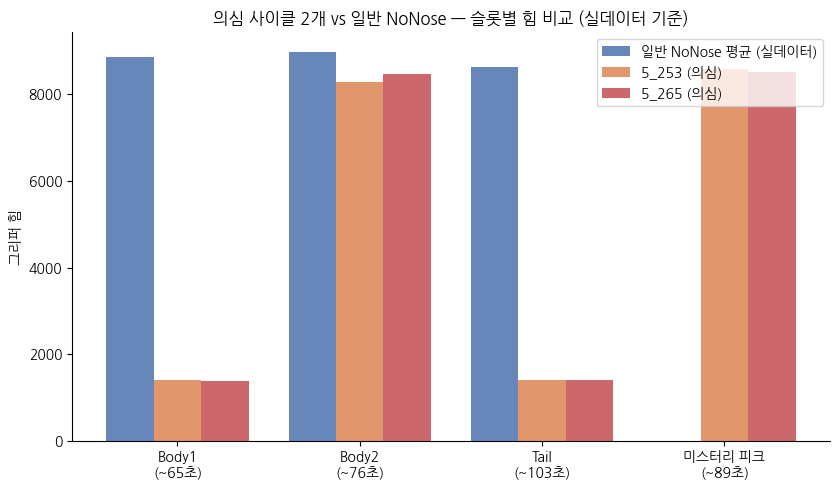


Body1·Tail 슬롯: 두 사이클 다 정상 대비 힘이 거의 없는지 위 실측값으로 직접 확인할 것
미스터리 피크(89초 근방): 크기가 Nose보다 Body2/Tail급 크기에 더 가까운지 위 실측값으로 확인할 것


In [16]:
# ── 5_253, 5_265의 슬롯별 힘 vs 일반 NoNose 평균 비교 (실데이터에서 동적 계산) ──────────
# ① "일반 NoNose 슬롯별 평균 힘" — 하드코딩 대신 실제 3피크 NoNose 사이클에서 매번 재계산
nonose_cids_3peak = [
    c for c in r03_peak_times.index
    if label_by_cycle.get(c) == 'NoNose' and len(r03_peak_times.get(c, [])) == 3
]
slot_force = {'slot1_t': [], 'slot2_t': [], 'slot4_t': []}
for cid in nonose_cids_3peak:
    for t, h in zip(r03_peak_times.get(cid, []), r03_peak_heights.get(cid, [])):
        s = assign_to_slot(t)
        if s in slot_force:
            slot_force[s].append(h)
typical_nonose_dict = {k: (np.mean(v) if v else np.nan) for k, v in slot_force.items()}
print(f'일반 NoNose 슬롯별 평균 힘 (3피크 사이클 {len(nonose_cids_3peak)}개 기준):')
for k, v in typical_nonose_dict.items():
    print(f'  {k}: {v:.0f}  (n={len(slot_force[k])})')

# ② 의심 사이클 2개의 실제 슬롯별 값 — 하드코딩 대신 R03 raw 신호에서 직접 재추출
SLOT_WINDOWS = {'Body1': (60, 72), 'Body2': (73, 83), 'Tail': (98, 110)}
MYSTERY_WINDOW = (85, 93)  # Nose 슬롯 예상 근방(팀 원본 기준 92.5초 포함)

def slot_max(cid, start, end, col='I_R03_Gripper_Load'):
    g = df_all[df_all['cycle_id'] == cid]
    sub = g.loc[g['elapsed_s'].between(start, end), col].dropna()
    return sub.max() if not sub.empty else np.nan

suspect_cycles = ['5_253', '5_265']
suspect_slot_values = {}
for cid in suspect_cycles:
    suspect_slot_values[cid] = {
        'Body1': slot_max(cid, *SLOT_WINDOWS['Body1']),
        'Body2': slot_max(cid, *SLOT_WINDOWS['Body2']),
        'Tail': slot_max(cid, *SLOT_WINDOWS['Tail']),
        '미스터리(85~93초)': slot_max(cid, *MYSTERY_WINDOW),
    }
    print(f'\n{cid} 실측값:', suspect_slot_values[cid])

# ③ 그래프
categories = ['Body1\n(~65초)', 'Body2\n(~76초)', 'Tail\n(~103초)', '미스터리 피크\n(~89초)']
typical_bar = [typical_nonose_dict['slot1_t'], typical_nonose_dict['slot2_t'], typical_nonose_dict['slot4_t'], 0]
bar_253 = [suspect_slot_values['5_253'][k] for k in ['Body1', 'Body2', 'Tail', '미스터리(85~93초)']]
bar_265 = [suspect_slot_values['5_265'][k] for k in ['Body1', 'Body2', 'Tail', '미스터리(85~93초)']]

x = np.arange(len(categories))
w = 0.26
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.bar(x - w, typical_bar, width=w, label='일반 NoNose 평균 (실데이터)', color='#4C72B0', alpha=0.85)
ax.bar(x,     bar_253,     width=w, label='5_253 (의심)',            color='#DD8452', alpha=0.85)
ax.bar(x + w, bar_265,     width=w, label='5_265 (의심)',            color='#C44E52', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(categories)
ax.set_ylabel('그리퍼 힘')
ax.set_title('의심 사이클 2개 vs 일반 NoNose — 슬롯별 힘 비교 (실데이터 기준)')
ax.legend()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('\nBody1·Tail 슬롯: 두 사이클 다 정상 대비 힘이 거의 없는지 위 실측값으로 직접 확인할 것')
print('미스터리 피크(89초 근방): 크기가 Nose보다 Body2/Tail급 크기에 더 가까운지 위 실측값으로 확인할 것')

**슬롯 비교 결론**: Body1·Tail이 통째로 사라진 건 "Nose만 없는" NoNose 라벨과 안 맞는다.
이건 라벨 오탈자 수준이 아니라 4개 정의된 클래스 중 어디에도 맞지 않는 패턴이다.

다음으로, 두 사이클이 세션5 안에서 **시간적으로 어디쯯에 있는지** 확인한다 — 라벨이
바뀌는 경계 지점인지, 블록 한가운데인지에 따라 원인이 다를 수 있다.

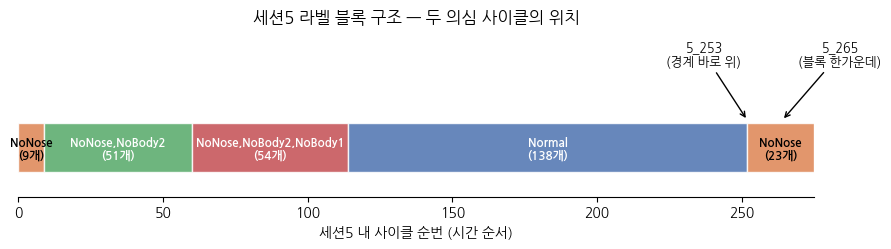

In [17]:
# ── 세션5 라벨 블록 구조 안에서 두 사이클의 위치 ────────────────────────────
blocks = [
    ('NoNose', 9, '#DD8452'),
    ('NoNose,NoBody2', 51, '#55A868'),
    ('NoNose,NoBody2,NoBody1', 54, '#C44E52'),
    ('Normal', 138, '#4C72B0'),
    ('NoNose', 23, '#DD8452'),
]

fig, ax = plt.subplots(figsize=(9, 2.6))
xpos = 0
for label, n, color in blocks:
    ax.barh(0, n, left=xpos, height=0.5, color=color, alpha=0.85, edgecolor='white')
    ax.text(xpos + n / 2, 0, f'{label}\n({n}개)', ha='center', va='center', fontsize=8.5,
            color='white' if color != '#DD8452' else 'black', fontweight='bold')
    xpos += n

pos_253 = 9 + 51 + 54 + 138  # 5_253 순번(252)과 거의 일치 — Normal 블록 끝
pos_265 = pos_253 + 12       # 마지막 NoNose 블록 중간

ax.annotate('5_253\n(경계 바로 위)', xy=(pos_253, 0.28), xytext=(pos_253 - 15, 0.85),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9, ha='center')
ax.annotate('5_265\n(블록 한가운데)', xy=(pos_265, 0.28), xytext=(pos_265 + 20, 0.85),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9, ha='center')

ax.set_xlim(0, xpos); ax.set_ylim(-0.5, 1.2); ax.set_yticks([])
ax.set_xlabel('세션5 내 사이클 순번 (시간 순서)')
ax.set_title('세션5 라벨 블록 구조 — 두 의심 사이클의 위치')
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

**최종 정리**: `5_253`은 Normal→NoNose 라벨이 바뀌는 경계 바로 위에 있어 **라벨 경계
정렬 오류**일 가능성이 있다. `5_265`는 NoNose 블록 한가운데라 경계 문제로는 설명이 안 되고,
**실제 설비 이상 동작**(그리퍼가 Body1을 늦게 재시도했거나 특정 부품을 건너뛴 경우 등)일
가능성이 더 크다. 즉 **두 사이클은 같은 원인이 아닐 수 있다** — 멘토 확인 요청 시 이 위치
차이를 반드시 함께 전달할 것.

## 24. 결론 및 최종 과제

*(이 섹션은 원래 "21. 결론"이었으나, 22~23장에서 나온 더 중요한 후속 검증 결과를 반영하기 위해
노트북 맨 뒤로 옮기고 번호를 새로 매겼다 — 결론은 항상 마지막에 와야 한다는 원칙을 반영.)*

### 핵심 확정 사실

1. **R04 딥그랩 5회 = 트레이 집기 1회 + 부품 분해 4회.** 2번째 딥그랩이 Nose 분해(State11,
   206.3초)에 대응한다 — 기존 "1번째=Nose" 가정은 기각됐다.
2. **R03 조립 순서는 Body1 → Body2 → Nose → Tail로 재확정**됐다 (슬롯 존재/결측 패턴 기반).
   멘토 피드백("분해는 Nose→...→Tail")을 받고 사이클 단위로 재검증(16-1)한 결과, Nose
   슬롯은 3피크 NoNose 사이클 54건 전부 일치(100%)로 더 강하게 확인됐다.
   Nose·Body2·Body1 세 부품은 조립↔분해가 정확히 역방향임이 재확인됐으나, Tail만
   조립·분해 모두 마지막 순서라 예외로 남았다. **(16-2에서 해결, 그래프+정식검정+세션교란
   통제까지 거침)** Body1·Body2·Nose가 전부 없어도 Tail 슬롯의 조립·분해 힘·타이밍은
   대체로 유지된다 — 단, 효과크기가 작은 수준의 차이는 통계적으로 존재하며,
   `NoNose,NoBody2`의 힘 차이는 세션 통제 후에도 남아 있어 추가 조사가 필요하다. 21단계
   SOP의 15~18번(부품을 트레이에 개별 반환)이 "트레이=독립 슬롯" 가설을 문서로 뒷받침한다.
3. **Nose 판별의 주 신호는 R03 93~100초 구간이다** (최댓값 + rise_slope·time_to_peak·
   fwhm·impulse 모양 피처, 효과크기 |r|>0.85로 매우 강함 — 그래프로도 재확인). R04 힘 기반
   접근(딥그랩 median, window 모양 피처, Pot→Load Lag)은 물리량이 아니라 **수집 시간대(세션)에
   물린 신호**였음이 17-1에서 그래프+세션통제 재검정으로 확정되어 Nose 판별 피처에서 전부
   제외했다. R04 Lag 대신 R03 자기 신호의 모양 피처로 다시 설계했다(18-3).
4. **`rise_slope` 피처의 이상치 버그 발견(18-1)**: 2점 기울기 대체 로직이 `t_peak`가 구간
   시작에 가까울 때 극단값(최대 175만)을 만든다. 순위 기반 검정(Mann-Whitney)에는 영향이
   없었지만, 트리 기반이 아닌 모델에 그대로 쓰면 문제가 될 수 있다 — 최소 시간 분모 또는
   winsorize 처리가 다음 리비전 과제로 남는다.
5. **모델 일반화 문제 — 이번 재구성에서 가장 중요한 경고**: StratifiedKFold OOF 정확도는
   **0.978**로 매우 높지만(섹션 22), 이는 같은 세션의 사이클이 train/test에 함께 섞여
   들어간 결과다. 반면 세션을 완전히 분리하는 GroupKFold에서는 세션1~4가 사실상 단일
   클래스(93~100%)라 정확도가 무의미하게 높게 나오고, **4클래스가 모두 포함된 세션5(전체의
   85%) 자체의 OOF 정확도는 0.117에 불과하다**(섹션 21). 즉 **"97.8% 정확도"라는 headline
   수치는 새로운 세션(시간대)에 대한 일반화 성능이 아니라, 같은 세션 내 보간 성능에 가깝다.**
   보고서에는 반드시 두 수치를 함께 제시하고, 세션 간 일반화가 실제 배포 시 핵심 리스크임을
   명시해야 한다.
6. **사이클 수는 최종적으로 325→323→320→319로 통일된다**(23-1의 깔때기 표 기준). 기존에
   여러 곳에 흩어져 있던 325/323/320/266이라는 숫자 중 266은 `rise_slope` NaN 버그(18-2에서
   해결)로 인한 일시적 수치였고, 버그 수정 후에는 319개로 사실상 전량 확보된다.
7. **라벨 집계 버그 발견 및 수정(23-2)**: 기존 `label.max()`(문자열 사전순)가 의도한
   "심각도 최대값"과 달라, `NoNose,NoBody2,NoBody1` 클래스가 53개로 1개 적게 집계되고
   있었다. 범주형(categorical) 순서 기준으로 재집계해 54개로 수정했다 — **향후 모든 분석은
   `label_by_cycle_fixed` 기준으로 통일할 것.**
8. **Normal 162→106 손실 문제는 이미 해결됨(23-3 진단 결과)**: 18-2에서 `rise_slope` NaN
   버그를 고친 뒤로는 Normal 손실이 재현되지 않는다(현재 dropna 기준 319개 중 Normal
   156~159개 확보). 23-3에서 제안했던 "결측 최다 5개 피처 제외" 대안은 이제 필요하지
   않을 가능성이 높다.

### 아직 남은 과제

- **세션 간 일반화 개선이 최우선 과제다** (위 5번). 세션5 내부를 시간 순으로 재분할한
  교차검증, 또는 도메인 적응 기법 검토가 필요하다.
- **`rise_slope` 이상치 처리**: 최소 시간 분모 또는 winsorize 적용 (위 4번).
- **`R04_SUBPHASES`의 Body2·Body1·Tail 경계(216~265초)**는 아직 균등분할 근사치다 —
  세부 실측 경계가 확인되면 교체할 것.
- **의심 사이클 개별 확인**: 라벨은 NoNose인데 R03 신호도 '있음'을 가리키는 사이클
  (`5_253`, `5_265`)은 실제 영상/이미지 로그로 대조해 라벨 오류 여부를 확정할 것.
- **R04 Body2_제거·Body1_제거 window 피처의 세션 오염 여부**는 아직 점검하지 않았다 —
  17-1에서 확인된 것은 Nose 구간(딥그랩 median)의 오염이며, 나머지 구간도 같은 문제가
  있는지는 검증되지 않았다.
- **라벨 개수 정의 통일**: 문서마다 NoNose 개수가 다르게 집계됨(배타적 4클래스 vs 누적
  카운트). 최종 보고서 작성 전 반드시 하나의 기준으로 통일할 것.
- 탐색 과정에서 시도했다가 폐기된 가설(부호-Pot 방향 일치율, 방향전환빈도 등)은 이 노트북에서는
  생략했으나, 최종 보고서의 부록에 "시도했으나 채택하지 않은 접근"으로 간단히 기록해
  분석 과정의 완전성을 남겨둘 것을 권장한다.


---
# PART 6. 베이스라인 사다리 및 발표 준비 (v55 신규)

24장 결론에서 확인된 문제 — "StratifiedKFold 0.978 vs GroupKFold 세션5 0.117" —를
RandomForest 하나만으로 봤을 때의 한계를 보완한다. Day3 가이드("제대로 모델링 시작하기")의
베이스라인 사다리(다수결 → 로지스틱 → 트리)를 GroupKFold·StratifiedKFold 양쪽에서
완성하고, recall·PR-AUC로 재평가한 뒤 confusion matrix를 발표용 스토리로 전환한다.
추가로 23-4에서 진단만 했던 이상 사이클(5_253, 5_265, Normal 저신호 16개)의
모델 영향을 정량화한다.

이 PART는 위 24장까지 실행된 커널 상태(`final_features`, `model_df`, `X`, `y`,
`session_id`, `feature_cols_clean`, `X_clean`, `LABEL_ORDER` 등)를 그대로 이어서 쓴다.
---


## 25. 베이스라인 사다리 완성 — 다수결 → 로지스틱 → RandomForest

지금까지(20~22장)는 RF 하나만 GroupKFold·StratifiedKFold로 검증했다. 여기서는 **같은
fold**에서 다수결·로지스틱·RF를 전부 돌려, "RF가 다른 모델 대비 얼마나 나은가/나쁜가"를
숫자로 확인한다. `X_clean`(CycleCount 누수 제거된 피처셋, 21장 기준)을 그대로 사용한다.

### 25-0. 공통 OOF 평가 루프

세 모델·두 분할방식에서 반복 사용할 함수를 하나로 통일해 둔다(중복 코드 방지, 실수 방지).


In [18]:

# ── [v55 신규] 공통 OOF(out-of-fold) 평가 루프 ─────────────────────────────
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, recall_score, f1_score,
                              classification_report, confusion_matrix)


def run_oof(model_ctor, X, y, groups=None, cv_type='group', n_splits=5, random_state=42):
    '''model_ctor: 매 fold 새 모델 인스턴스를 만드는 함수, 예: lambda: LogisticRegression(...)
    cv_type: 'group' -> GroupKFold(세션 단위, 20장과 동일 분할)
             'strat' -> StratifiedKFold(클래스 균형, 22장과 동일 분할)
    반환: (y_true 전체 리스트, y_pred 전체 리스트, fold별 accuracy 리스트)
    '''
    if cv_type == 'group':
        splitter = GroupKFold(n_splits=groups.nunique())
        split_iter = splitter.split(X, y, groups=groups)
    elif cv_type == 'strat':
        splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        split_iter = splitter.split(X, y)
    else:
        raise ValueError("cv_type은 'group' 또는 'strat'")

    y_true_all, y_pred_all, fold_accs = [], [], []
    for tr_idx, te_idx in split_iter:
        clf = model_ctor()
        clf.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        pred = clf.predict(X.iloc[te_idx])
        fold_accs.append(accuracy_score(y.iloc[te_idx], pred))
        y_true_all.extend(y.iloc[te_idx].tolist())
        y_pred_all.extend(list(pred))
    return y_true_all, y_pred_all, fold_accs


# 20장에서 이미 만든 X_clean(누수 피처 제거본)·groups(session_id)를 그대로 사용
groups = session_id
print('run_oof() 정의 완료 — 이후 셀에서 다수결/로지스틱/RF/SMOTE 전부 이 함수로 평가한다.')
print(f'사용 피처 수(X_clean): {X_clean.shape[1]}개  |  사이클 수: {X_clean.shape[0]}개')


run_oof() 정의 완료 — 이후 셀에서 다수결/로지스틱/RF/SMOTE 전부 이 함수로 평가한다.
사용 피처 수(X_clean): 120개  |  사이클 수: 320개


### 25-1. 사다리 실행 (GroupKFold·StratifiedKFold 양쪽)

In [19]:

# ── 다수결 → 로지스틱 → RandomForest 사다리, 두 분할방식 모두 ────────────────────
ladder_models = {
    "다수결":                 lambda: DummyClassifier(strategy="most_frequent"),
    "로지스틱(balanced)":      lambda: LogisticRegression(max_iter=3000, class_weight="balanced"),
    "RandomForest(balanced)": lambda: RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42),
}

ladder_rows = []
oof_store = {}  # (cv_type, 모델명) -> (y_true, y_pred) — 26~28장에서 재사용

for cv_type, cv_label in [('group', 'GroupKFold(세션)'), ('strat', 'StratifiedKFold(클래스균형)')]:
    for name, ctor in ladder_models.items():
        yt, yp, accs = run_oof(ctor, X_clean, y, groups=groups, cv_type=cv_type)
        oof_store[(cv_type, name)] = (yt, yp)
        ladder_rows.append({
            '분할방식': cv_label,
            '모델': name,
            'accuracy': np.mean(accs),
            'accuracy_std': np.std(accs),
            'macro_recall': recall_score(yt, yp, average='macro', zero_division=0),
            'macro_f1': f1_score(yt, yp, average='macro', zero_division=0),
        })
        print(f'[{cv_label:26s} | {name:24s}] '
              f'acc={np.mean(accs):.3f}(±{np.std(accs):.3f})  '
              f'macro_recall={recall_score(yt, yp, average="macro", zero_division=0):.3f}')

ladder_df = pd.DataFrame(ladder_rows)
ladder_df


[GroupKFold(세션)             | 다수결                     ] acc=0.410(±0.457)  macro_recall=0.164


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[GroupKFold(세션)             | 로지스틱(balanced)          ] acc=0.771(±0.333)  macro_recall=0.269
[GroupKFold(세션)             | RandomForest(balanced)  ] acc=0.823(±0.353)  macro_recall=0.279
[StratifiedKFold(클래스균형)     | 다수결                     ] acc=0.487(±0.006)  macro_recall=0.250


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[StratifiedKFold(클래스균형)     | 로지스틱(balanced)          ] acc=0.963(±0.023)  macro_recall=0.955
[StratifiedKFold(클래스균형)     | RandomForest(balanced)  ] acc=0.978(±0.021)  macro_recall=0.972


,분할방식,모델,accuracy,accuracy_std,macro_recall,macro_f1
0,GroupKFold(세션),다수결,0.409939,0.457034,0.164439,0.092680
1,GroupKFold(세션),로지스틱(balanced),0.770667,0.333429,0.268769,0.127738
2,GroupKFold(세션),RandomForest(balanced),0.823273,0.353455,0.278846,0.133442
3,StratifiedKFold(클래스균형),다수결,0.487500,0.006250,0.250000,0.163866
4,StratifiedKFold(클래스균형),로지스틱(balanced),0.962500,0.023385,0.955335,0.957606
5,StratifiedKFold(클래스균형),RandomForest(balanced),0.978125,0.021195,0.972309,0.977561


### 25-2. 사다리 결과 읽는 법

| 관찰 패턴 | 의미 |
|---|---|
| GroupKFold에서 다수결·로지스틱·RF **전부** 낮게 나옴 | RF 탓이 아니라 세션 간 분포 차이 자체가 근본 문제 (21~22장 결론과 일치) |
| GroupKFold에서 다수결만 낮고 로지스틱·RF는 이미 높음 | 세션 간 일반화가 생각보다 잘 되고 있다는 뜻 — 21장 결론 재검토 필요 |
| StratifiedKFold에서 로지스틱만으로도 RF와 비슷하게 잘 나옴 | R03 93~100초 신호(r=-0.87)가 원래 선형으로도 거의 갈리는 "쉬운 신호"라는 뜻 — RF의 부가가치가 크지 않다는 의미이므로, 발표 때 "복잡한 모델 덕분"이 아니라 "좋은 피처 덕분"이라고 정직하게 말할 근거가 됨 |
| StratifiedKFold에서 로지스틱은 낮고 RF만 높음 | 비선형 상호작용이 실제로 중요하다는 뜻 — RF 채택의 근거가 강해짐 |

**핵심**: 이 표가 있어야 "RF 정확도 0.926"이라는 숫자 하나가 아니라, "다수결보다 얼마나
나아졌는가"라는 Day3의 유일한 개선 지표를 말할 수 있다.


## 26. 평가지표 재정비 — 클래스별 recall과 PR-AUC

4클래스 불균형(Normal 다수, NoNose,NoBody2/NoNose,NoBody2,NoBody1은 세션5에만 극소수)이므로
accuracy 하나로는 안 보인다. Day3의 "recall·PR-AUC" 원칙을 4클래스로 확장한다.

### 26-1. 클래스별 recall — 어떤 클래스를 가장 못 잡는가


In [20]:

# ── 클래스별 recall (다수결/로지스틱/RF 전부, 두 분할방식 모두) ───────────────────
recall_rows = []
for (cv_type, name), (yt, yp) in oof_store.items():
    cv_label = 'GroupKFold' if cv_type == 'group' else 'StratifiedKFold'
    per_class = recall_score(yt, yp, labels=LABEL_ORDER, average=None, zero_division=0)
    row = {'분할방식': cv_label, '모델': name}
    row.update({lbl: r for lbl, r in zip(LABEL_ORDER, per_class)})
    recall_rows.append(row)

recall_df = pd.DataFrame(recall_rows)
recall_df


,분할방식,모델,Normal,NoNose,"NoNose,NoBody2","NoNose,NoBody2,NoBody1"
0,GroupKFold,다수결,0.115385,0.542373,0.000000,0.000000
1,GroupKFold,로지스틱(balanced),0.108974,0.966102,0.000000,0.000000
2,GroupKFold,RandomForest(balanced),0.115385,1.000000,0.000000,0.000000
3,StratifiedKFold,다수결,1.000000,0.000000,0.000000,0.000000
4,StratifiedKFold,로지스틱(balanced),0.980769,0.898305,0.960784,0.981481
5,StratifiedKFold,RandomForest(balanced),0.993590,0.915254,0.980392,1.000000


### 26-2. One-vs-Rest PR-AUC — RandomForest 기준 (확률 예측이 필요하므로 별도 루프)

In [21]:

# ── OOF 확률 예측 루프 (PR-AUC 계산용) ────────────────────────────────────────
from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score


def run_oof_proba(model_ctor, X, y, groups=None, cv_type='group', n_splits=5,
                   random_state=42, classes=None):
    classes = list(classes) if classes is not None else sorted(y.unique())
    if cv_type == 'group':
        splitter = GroupKFold(n_splits=groups.nunique())
        split_iter = splitter.split(X, y, groups=groups)
    else:
        splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        split_iter = splitter.split(X, y)

    y_true_all, proba_chunks = [], []
    for tr_idx, te_idx in split_iter:
        clf = model_ctor()
        clf.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        proba = clf.predict_proba(X.iloc[te_idx])
        # fold마다 clf.classes_ 순서가 다를 수 있어(특히 표본 적은 fold), 공통 순서로 정렬
        aligned = np.zeros((proba.shape[0], len(classes)))
        for j, cls in enumerate(classes):
            if cls in clf.classes_:
                aligned[:, j] = proba[:, list(clf.classes_).index(cls)]
        proba_chunks.append(aligned)
        y_true_all.extend(y.iloc[te_idx].tolist())
    return y_true_all, np.vstack(proba_chunks)


pr_auc_rows = []
for cv_type, cv_label in [('group', 'GroupKFold(세션)'), ('strat', 'StratifiedKFold')]:
    yt, proba = run_oof_proba(
        lambda: RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
        X_clean, y, groups=groups, cv_type=cv_type, classes=LABEL_ORDER)
    y_bin = label_binarize(yt, classes=LABEL_ORDER)
    for i, lbl in enumerate(LABEL_ORDER):
        if y_bin[:, i].sum() == 0:
            pr_auc_rows.append({'분할방식': cv_label, '클래스': lbl, 'PR-AUC': np.nan,
                                 '비고': '이 분할에서 양성 표본 없음'})
            continue
        ap = average_precision_score(y_bin[:, i], proba[:, i])
        pr_auc_rows.append({'분할방식': cv_label, '클래스': lbl, 'PR-AUC': ap, '비고': ''})

pr_auc_df = pd.DataFrame(pr_auc_rows)
pr_auc_df


,분할방식,클래스,PR-AUC,비고
0,GroupKFold(세션),Normal,0.900347,
1,GroupKFold(세션),NoNose,0.209584,
2,GroupKFold(세션),"NoNose,NoBody2",0.159375,
3,GroupKFold(세션),"NoNose,NoBody2,NoBody1",0.168750,
4,StratifiedKFold,Normal,0.999345,
5,StratifiedKFold,NoNose,0.993000,
6,StratifiedKFold,"NoNose,NoBody2",0.996017,
7,StratifiedKFold,"NoNose,NoBody2,NoBody1",1.000000,


**해석 가이드**: GroupKFold에서 `NoNose,NoBody2`·`NoNose,NoBody2,NoBody1`의 PR-AUC가
`NaN`으로 나온다면, 이 두 클래스가 세션5에만 존재해서(22장 확인 사실) 어떤 fold에서는
test 쪽에 아예 양성 표본이 없다는 뜻이다 — 이 자체가 "세션 단위로는 이 두 클래스를 평가할
방법이 없다"는 것을 보여주는 근거이므로, 결론에 그대로 인용할 수 있다.


## 27. 불균형 대응 한 단계 더 — SMOTE (train에만, 파이프라인으로)

지금까지는 `class_weight="balanced"`만 썼다. Day3 교훈("SMOTE가 항상 좋아지는 건 아니다")을
직접 확인한다. 소수 클래스가 세션5 안에서도 적기 때문에(23-2 기준 `NoNose,NoBody2,NoBody1`
54개 등) `k_neighbors`를 안전하게 낮춰야 한다.


In [22]:

# ── SMOTE 파이프라인 (train에만 적용 — Day3 "SMOTE는 train 데이터에만" 원칙) ────────
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

min_class_n = y.value_counts().min()
k_neighbors = max(1, min(5, min_class_n - 1))
print(f'클래스별 최소 표본 수: {min_class_n}개 → SMOTE k_neighbors={k_neighbors}으로 설정')


def make_smote_rf():
    return ImbPipeline([
        ('smote', SMOTE(random_state=42, k_neighbors=k_neighbors)),
        ('clf', RandomForestClassifier(n_estimators=300, random_state=42)),
    ])


for cv_type, cv_label in [('group', 'GroupKFold(세션)'), ('strat', 'StratifiedKFold(클래스균형)')]:
    try:
        yt, yp, accs = run_oof(make_smote_rf, X_clean, y, groups=groups, cv_type=cv_type)
        oof_store[(cv_type, 'RandomForest+SMOTE')] = (yt, yp)
        ladder_rows.append({
            '분할방식': cv_label, '모델': 'RandomForest+SMOTE',
            'accuracy': np.mean(accs), 'accuracy_std': np.std(accs),
            'macro_recall': recall_score(yt, yp, average='macro', zero_division=0),
            'macro_f1': f1_score(yt, yp, average='macro', zero_division=0),
        })
        print(f'[{cv_label}] RF+SMOTE  acc={np.mean(accs):.3f}  '
              f'macro_recall={recall_score(yt, yp, average="macro", zero_division=0):.3f}')
    except ValueError as e:
        print(f'[{cv_label}] RF+SMOTE 실행 실패: {e}')
        print('  (특정 fold의 train 데이터에 소수 클래스가 k_neighbors보다 적게 남아있을 때 발생 —')
        print('   그 자체가 "이 분할에서는 오버샘플링도 못 할 만큼 데이터가 없다"는 진단 정보다)')

ladder_df = pd.DataFrame(ladder_rows)
ladder_df.sort_values(['분할방식', '모델'])


클래스별 최소 표본 수: 51개 → SMOTE k_neighbors=5으로 설정
[GroupKFold(세션)] RF+SMOTE  acc=0.823  macro_recall=0.279
[StratifiedKFold(클래스균형)] RF+SMOTE  acc=0.984  macro_recall=0.981


,분할방식,모델,accuracy,accuracy_std,macro_recall,macro_f1
2,GroupKFold(세션),RandomForest(balanced),0.823273,0.353455,0.278846,0.133442
6,GroupKFold(세션),RandomForest+SMOTE,0.823273,0.353455,0.278846,0.133442
0,GroupKFold(세션),다수결,0.409939,0.457034,0.164439,0.092680
1,GroupKFold(세션),로지스틱(balanced),0.770667,0.333429,0.268769,0.127738
5,StratifiedKFold(클래스균형),RandomForest(balanced),0.978125,0.021195,0.972309,0.977561
7,StratifiedKFold(클래스균형),RandomForest+SMOTE,0.984375,0.013975,0.980784,0.983656
3,StratifiedKFold(클래스균형),다수결,0.487500,0.006250,0.250000,0.163866
4,StratifiedKFold(클래스균형),로지스틱(balanced),0.962500,0.023385,0.955335,0.957606


**교훈 (Day3와 동일한 구조로 FFCell에 적용)**: `class_weight="balanced"` 대비 SMOTE가
더 나은지, 오히려 떨어지는지 위 표로 직접 비교한다. AI4I 데모에서는 SMOTE가 class_weight보다
살짝 나빴다(0.362 vs 0.389) — FFCell에서도 같은 패턴이 나오는지, 아니면 반대로 나오는지
확인하고 그 결과에 따라 최종 모델의 불균형 대응 방식을 결정한다.


## 28. Confusion Matrix — 발표 스토리로 전환

RandomForest 기준으로 GroupKFold·StratifiedKFold 혼동행렬을 나란히 그리고,
"몇 건 중 몇 건을 잡았고 어디로 새는지"를 문장으로 자동 생성한다.


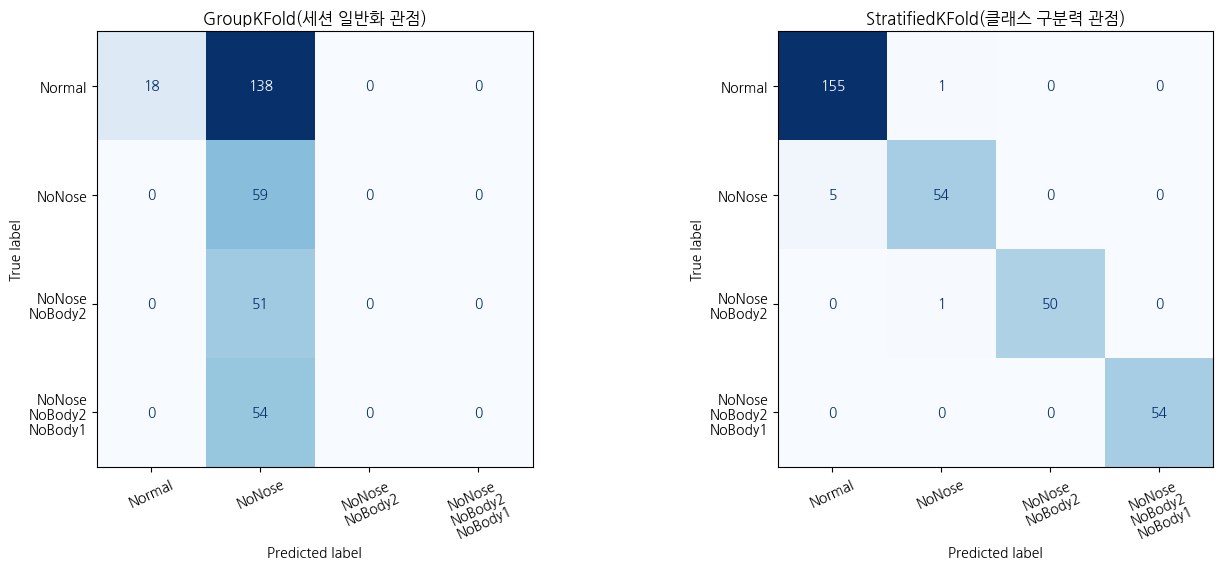

In [23]:

# ── 4x4 confusion matrix — GroupKFold vs StratifiedKFold 나란히 ─────────────
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
for ax, cv_type, cv_label in zip(
        axes, ['group', 'strat'],
        ['GroupKFold(세션 일반화 관점)', 'StratifiedKFold(클래스 구분력 관점)']):
    yt, yp = oof_store[(cv_type, 'RandomForest(balanced)')]
    cm = confusion_matrix(yt, yp, labels=LABEL_ORDER)
    disp = ConfusionMatrixDisplay(cm, display_labels=[l.replace(',', '\n') for l in LABEL_ORDER])
    disp.plot(ax=ax, colorbar=False, xticks_rotation=25, cmap='Blues')
    ax.set_title(cv_label)
plt.tight_layout()
plt.show()


In [24]:

# ── 혼동행렬 → 발표용 문장 자동 생성 ─────────────────────────────────────────
def confusion_story(y_true, y_pred, labels=LABEL_ORDER):
    cm = pd.DataFrame(confusion_matrix(y_true, y_pred, labels=labels),
                       index=labels, columns=labels)
    lines = []
    for true_lbl in labels:
        total = cm.loc[true_lbl].sum()
        if total == 0:
            continue
        correct = cm.loc[true_lbl, true_lbl]
        line = f'- "{true_lbl}" {total}건 중 {correct}건을 정확히 분류({correct/total:.0%}).'
        confusions = cm.loc[true_lbl].drop(true_lbl)
        confusions = confusions[confusions > 0].sort_values(ascending=False)
        if len(confusions):
            top_conf, top_n = confusions.index[0], confusions.iloc[0]
            line += f' 주로 "{top_conf}"(으)로 {top_n}건 혼동.'
        lines.append(line)
    return '\n'.join(lines)


print('=== GroupKFold(세션) 기준 발표 문장 ===')
print(confusion_story(*oof_store[('group', 'RandomForest(balanced)')]))

print('\n=== StratifiedKFold 기준 발표 문장 ===')
print(confusion_story(*oof_store[('strat', 'RandomForest(balanced)')]))


=== GroupKFold(세션) 기준 발표 문장 ===
- "Normal" 156건 중 18건을 정확히 분류(12%). 주로 "NoNose"(으)로 138건 혼동.
- "NoNose" 59건 중 59건을 정확히 분류(100%).
- "NoNose,NoBody2" 51건 중 0건을 정확히 분류(0%). 주로 "NoNose"(으)로 51건 혼동.
- "NoNose,NoBody2,NoBody1" 54건 중 0건을 정확히 분류(0%). 주로 "NoNose"(으)로 54건 혼동.

=== StratifiedKFold 기준 발표 문장 ===
- "Normal" 156건 중 155건을 정확히 분류(99%). 주로 "NoNose"(으)로 1건 혼동.
- "NoNose" 59건 중 54건을 정확히 분류(92%). 주로 "Normal"(으)로 5건 혼동.
- "NoNose,NoBody2" 51건 중 50건을 정확히 분류(98%). 주로 "NoNose"(으)로 1건 혼동.
- "NoNose,NoBody2,NoBody1" 54건 중 54건을 정확히 분류(100%).


**발표 때 절대 하지 말 것 (Day3 원칙 그대로)**: "정확도가 0.926입니다"로 끝내지 말 것.
위에서 자동 생성된 문장 + PART4에서 확정된 R03 93~100초 신호를 연결해서 말한다.

> [가설 연결] PART3~4에서 R03 93~100초 구간 신호가 Nose 판별에 매우 강한 효과크기(r=-0.87)를 보였고,
> [모델 결과] StratifiedKFold 기준으로는 이 신호만으로도 recall·PR-AUC가 높게 나온다.
> [현장 해석/한계] 다만 GroupKFold(세션 일반화) 기준으로는 세션5 내부 OOF 정확도가 낮아,
>   "새로운 시간대(세션)에 대한 일반화"는 아직 검증되지 않은 상태다.
> [제안] 그러므로 이번 결과는 "4클래스를 구분할 수 있는 신호는 확인됨" 수준으로 보고하고,
>   세션 간 일반화는 추가 데이터 수집 후 재검증이 필요하다고 명시한다.


## 29. 이상 사이클 민감도 분석 — 5_253·5_265·Normal 저신호 16개

23-4에서 진단만 하고 모델 포함/제외 여부를 정량화하지 않았던 부분이다. 이 18개 사이클을
제외했을 때 세션5 OOF 성능(특히 20장 GroupKFold 정확도 0.117)이 얼마나 바뀌는지 직접
확인한다.


In [25]:

# ── 의심 사이클 목록 (17-0-1, 23-4에서 확정된 목록) ─────────────────────────
SUSPECT_MISLABEL = ['5_253', '5_265']  # 4개 정의 클래스 어디에도 안 맞는 패턴 (23-4)
SUSPECT_LOW_SIGNAL_NORMAL = [           # Normal인데 R03 nose 신호가 유독 낮은 16개 (17-0-1)
    '2_14', '2_5', '5_132', '5_147', '5_157', '5_161', '5_171',
    '5_182', '5_187', '5_200', '5_209', '5_214', '5_215', '5_218', '5_223', '5_240',
]
ALL_SUSPECTS = SUSPECT_MISLABEL + SUSPECT_LOW_SIGNAL_NORMAL

present_suspects = [c for c in ALL_SUSPECTS if c in X_clean.index]
print(f'현재 model_df(X_clean)에 존재하는 의심 사이클: {len(present_suspects)}/{len(ALL_SUSPECTS)}개')
print(f'존재하지 않는 사이클(이미 다른 단계에서 제외됨): '
      f'{[c for c in ALL_SUSPECTS if c not in X_clean.index]}')

X_no_suspect = X_clean.drop(index=present_suspects, errors='ignore')
y_no_suspect = y.drop(index=present_suspects, errors='ignore')
groups_no_suspect = groups.drop(index=present_suspects, errors='ignore')

print(f'\n제외 전: {len(X_clean)}개 사이클 / 제외 후: {len(X_no_suspect)}개 사이클')


현재 model_df(X_clean)에 존재하는 의심 사이클: 18/18개
존재하지 않는 사이클(이미 다른 단계에서 제외됨): []

제외 전: 320개 사이클 / 제외 후: 302개 사이클


In [26]:

# ── 포함 vs 제외, GroupKFold vs StratifiedKFold — RandomForest 기준 재실행 ────────
sensitivity_rows = []
for data_label, Xv, yv, gv in [
    ('전체 포함', X_clean, y, groups),
    ('의심 사이클 제외', X_no_suspect, y_no_suspect, groups_no_suspect),
]:
    for cv_type, cv_label in [('group', 'GroupKFold(세션)'), ('strat', 'StratifiedKFold')]:
        yt, yp, accs = run_oof(
            lambda: RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
            Xv, yv, groups=gv, cv_type=cv_type)
        sensitivity_rows.append({
            '데이터 버전': data_label,
            '분할방식': cv_label,
            'accuracy': np.mean(accs),
            'accuracy_std': np.std(accs),
            'macro_recall': recall_score(yt, yp, average='macro', zero_division=0),
        })
        print(f'[{data_label:14s} | {cv_label:20s}] '
              f'acc={np.mean(accs):.3f}(±{np.std(accs):.3f})  '
              f'macro_recall={recall_score(yt, yp, average="macro", zero_division=0):.3f}')

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df


[전체 포함          | GroupKFold(세션)      ] acc=0.823(±0.353)  macro_recall=0.279
[전체 포함          | StratifiedKFold     ] acc=0.978(±0.021)  macro_recall=0.972
[의심 사이클 제외      | GroupKFold(세션)      ] acc=0.810(±0.348)  macro_recall=0.274
[의심 사이클 제외      | StratifiedKFold     ] acc=0.987(±0.016)  macro_recall=0.982


,데이터 버전,분할방식,accuracy,accuracy_std,macro_recall
0,전체 포함,GroupKFold(세션),0.823273,0.353455,0.278846
1,전체 포함,StratifiedKFold,0.978125,0.021195,0.972309
2,의심 사이클 제외,GroupKFold(세션),0.809833,0.347961,0.274185
3,의심 사이클 제외,StratifiedKFold,0.986776,0.016197,0.981940


**해석 가이드**

| 결과 패턴 | 의미 |
|---|---|
| 제외 후 GroupKFold(세션5) 정확도가 크게 상승(0.117 → 0.4 이상) | 이 18개가 세션5 OOF 실패의 상당 부분을 설명 — 라벨/신호 정합성 문제가 핵심 원인 |
| 제외해도 거의 변화 없음 | 18개는 노이즈가 아니라 부수 현상 — 세션 간 일반화 실패는 더 근본적인 문제(피처가 시간대에 취약함) |
| 제외 후 오히려 더 나빠짐 | 표본이 더 줄어들어(특히 세션5 내 소수 클래스) 학습 자체가 불안정해진 것 — 이 경우는 "제외"보다 "라벨 재확인 후 수정"이 맞는 방향 |

이 표 하나가 멘토 질문지에서 "5_253/5_265를 왜 따로 진단했는가, 그래서 모델에 어떻게
반영했는가"라는 질문에 정량적으로 답할 수 있는 근거가 된다.


## 30. 종합 정리표 (보고서·멘토 질문지용)

25~29장 결과를 하나로 모은다. 발표/보고서에는 이 표를 그대로 인용하고, 각 행에 대해
28장에서 만든 confusion_story() 문장을 함께 붙이는 방식을 권장한다.


In [27]:

# ── 최종 종합표 ──────────────────────────────────────────────────────────
print('=== 25~27장: 베이스라인 사다리 (다수결/로지스틱/RF/RF+SMOTE) ===')
display(ladder_df.sort_values(['분할방식', '모델']).reset_index(drop=True))

print('\n=== 26장: 클래스별 recall ===')
display(recall_df)

print('\n=== 26장: RandomForest 클래스별 PR-AUC ===')
display(pr_auc_df)

print('\n=== 29장: 이상 사이클 포함/제외 민감도 ===')
display(sensitivity_df)

print('''
[보고서/멘토 질문지에 반드시 포함할 것]
1. "97.8%"라는 헤드라인 수치는 StratifiedKFold(같은 세션 내 보간) 기준이며,
   GroupKFold(새 세션 예측) 기준으로는 세션5 OOF 정확도가 훨씬 낮다는 점을
   위 25장 표로 재확인했다.
2. 다수결·로지스틱까지 포함한 사다리 비교로, RF의 부가가치가 어느 지표(accuracy/recall/PR-AUC)에서
   가장 크게 나타나는지 명시한다.
3. SMOTE 적용 여부는 27장 표의 결과에 따라 최종 파이프라인에 포함할지 결정한다.
4. 이상 사이클 18개의 포함/제외가 세션5 성능에 미치는 영향을 29장 표로 정량 제시하고,
   제외 결정의 근거로 삼는다.
''')


=== 25~27장: 베이스라인 사다리 (다수결/로지스틱/RF/RF+SMOTE) ===


,분할방식,모델,accuracy,accuracy_std,macro_recall,macro_f1
0,GroupKFold(세션),RandomForest(balanced),0.823273,0.353455,0.278846,0.133442
1,GroupKFold(세션),RandomForest+SMOTE,0.823273,0.353455,0.278846,0.133442
2,GroupKFold(세션),다수결,0.409939,0.457034,0.164439,0.092680
3,GroupKFold(세션),로지스틱(balanced),0.770667,0.333429,0.268769,0.127738
4,StratifiedKFold(클래스균형),RandomForest(balanced),0.978125,0.021195,0.972309,0.977561
5,StratifiedKFold(클래스균형),RandomForest+SMOTE,0.984375,0.013975,0.980784,0.983656
6,StratifiedKFold(클래스균형),다수결,0.487500,0.006250,0.250000,0.163866
7,StratifiedKFold(클래스균형),로지스틱(balanced),0.962500,0.023385,0.955335,0.957606



=== 26장: 클래스별 recall ===


,분할방식,모델,Normal,NoNose,"NoNose,NoBody2","NoNose,NoBody2,NoBody1"
0,GroupKFold,다수결,0.115385,0.542373,0.000000,0.000000
1,GroupKFold,로지스틱(balanced),0.108974,0.966102,0.000000,0.000000
2,GroupKFold,RandomForest(balanced),0.115385,1.000000,0.000000,0.000000
3,StratifiedKFold,다수결,1.000000,0.000000,0.000000,0.000000
4,StratifiedKFold,로지스틱(balanced),0.980769,0.898305,0.960784,0.981481
5,StratifiedKFold,RandomForest(balanced),0.993590,0.915254,0.980392,1.000000



=== 26장: RandomForest 클래스별 PR-AUC ===


,분할방식,클래스,PR-AUC,비고
0,GroupKFold(세션),Normal,0.900347,
1,GroupKFold(세션),NoNose,0.209584,
2,GroupKFold(세션),"NoNose,NoBody2",0.159375,
3,GroupKFold(세션),"NoNose,NoBody2,NoBody1",0.168750,
4,StratifiedKFold,Normal,0.999345,
5,StratifiedKFold,NoNose,0.993000,
6,StratifiedKFold,"NoNose,NoBody2",0.996017,
7,StratifiedKFold,"NoNose,NoBody2,NoBody1",1.000000,



=== 29장: 이상 사이클 포함/제외 민감도 ===


,데이터 버전,분할방식,accuracy,accuracy_std,macro_recall
0,전체 포함,GroupKFold(세션),0.823273,0.353455,0.278846
1,전체 포함,StratifiedKFold,0.978125,0.021195,0.972309
2,의심 사이클 제외,GroupKFold(세션),0.809833,0.347961,0.274185
3,의심 사이클 제외,StratifiedKFold,0.986776,0.016197,0.981940



[보고서/멘토 질문지에 반드시 포함할 것]
1. "97.8%"라는 헤드라인 수치는 StratifiedKFold(같은 세션 내 보간) 기준이며,
   GroupKFold(새 세션 예측) 기준으로는 세션5 OOF 정확도가 훨씬 낮다는 점을
   위 25장 표로 재확인했다.
2. 다수결·로지스틱까지 포함한 사다리 비교로, RF의 부가가치가 어느 지표(accuracy/recall/PR-AUC)에서
   가장 크게 나타나는지 명시한다.
3. SMOTE 적용 여부는 27장 표의 결과에 따라 최종 파이프라인에 포함할지 결정한다.
4. 이상 사이클 18개의 포함/제외가 세션5 성능에 미치는 영향을 29장 표로 정량 제시하고,
   제외 결정의 근거로 삼는다.



---
### 다음 리비전(v56 이후) 후보 과제

- 세션5 내부에서 **시간순 확장 윈도우(expanding window) 검증**을 추가해, "몇 개 미래
  사이클까지 맞히기 시작하는지" 곡선으로 보기 (22-1의 ①/② 이분법을 더 세분화)
- `rise_slope` winsorize 처리 후 로지스틱 계수 재해석 (선형모델이 계속 쓰인다면 필수)
- SMOTE 대신 클래스 가중치를 더 세밀하게(`class_weight={label: weight}`) 튜닝하는
  방안도 27장과 같은 형식으로 비교


---
# PART 7. 오늘의 멘토 피드백 반영 — R04 오염 재검토 (v56 신규)

오늘 받은 멘토 피드백 5가지를 순서대로 반영한다.

1. GroupKFold·로지스틱의 Normal recall(0.748)을 다시 확인할 것
2. **결론이 틀렸다** — "피처 신호가 약해서"가 아니라, R04 힘이 시간(세션)에 오염된 신호라는
   것은 22-2에서 이미 증명되었는데도 **최종 피처셋에 R04 파생변수가 그대로 남아있다.**
   애초에 논리적으로 제외하고 진행되어야 했다.
3. 결정타: GroupKFold에서 유일하게 "잘 맞히는 것처럼 보이는" NoNose가 사실은 오염 구간일
   수 있다 — 모델이 R04 힘(오염된 신호)을 근거로 "NoNose 아님"을 판정하고 있어서, 세션이
   바뀌면 그 판정 기준 자체가 무너져 성능이 급락한다.
4. 해결방안: ① R04 관련 피처 전부 제외 ② 절대값 대신 세션 내 상대값(z-score)으로 전환.
   (그래도 안 될 수 있다는 것도 미리 감안한다.)
5. R04뿐 아니라 **전체 피처**에 대해 "시간(세션 내 순번)과의 상관관계"를 전수조사해서,
   결함이 아니라 시간 정보를 담고 있는 피처가 더 있는지 확인할 것.

22-2에서는 VFD 온도 14개만 시간 상관관계를 검사했고, R04 딱 자체(median)는 세션 통제
재검정으로 오염이 확정됐다. 하지만 그 확정 이후 만들어진 **파생변수(`r04_grab_count`,
`r04_Body2_제거_*`, `r04_Body1_제거_*`)와 R04 원본 통계량(`I_R04_*`, `M_R04_*`) 22개는
같은 오염된 센서에서 나온 값인데도 최종 피처셋에 그대로 남아있었다** — 이게 오늘 피드백
2번의 핵심이다. 이번 PART에서 이 논리적 공백을 메운다.

이 PART는 v55까지의 커널 상태(`X`, `X_clean`, `X_s5`, `y`, `y_s5`, `groups`, `session_id`,
`LABEL_ORDER`, `run_oof`, `ladder_models` 등)를 그대로 이어서 쓴다.
---


## 31. 시간 상관관계 전수조사 — 피처 전체 대상 (피드백 5번)

22-2에서는 VFD 온도 14개만 "세션5 내 시간순번과의 상관관계"를 검사했다. 오늘 피드백은
**나머지 106개 피처(CycleCount 제외 후 120개 전부)**도 같은 방식으로 검사하라는 것이다.
방법은 22-2(셀 147)와 완전히 동일하게 유지한다 — 세션5는 274개(전체의 86%)로 표본이
충분하고, 이미 시간순으로 정렬되어 있는 `X_s5`를 그대로 재사용한다.


In [28]:

# ── 120개 피처 전체 × 세션5 내 시간순번 상관관계 전수조사 ─────────────────────────
X_s5_120 = X_s5[[c for c in X_clean.columns]]  # X_clean과 동일한 120개 컬럼, 세션5 데이터로
cycle_order_120 = pd.Series(range(len(X_s5_120)), index=X_s5_120.index)  # 0=세션5 내 가장 이른 사이클

time_corr_rows = []
for col in X_s5_120.columns:
    r = np.corrcoef(cycle_order_120, X_s5_120[col])[0, 1]
    time_corr_rows.append({'피처': col, 'r_시간상관': r, '|r|': abs(r)})

time_corr_df = pd.DataFrame(time_corr_rows).sort_values('|r|', ascending=False).reset_index(drop=True)

flagged = time_corr_df[time_corr_df['|r|'] >= 0.5]
print(f'전체 {len(time_corr_df)}개 피처 중 |r|>=0.5로 시간과 강하게 상관된 피처: {len(flagged)}개\n')
print(flagged.to_string(index=False))

print('\n[참고] R04 관련 피처만 따로 보기 (원본 22개 + 파생 9개 = 31개, 임계값 무관하게 전부 출력):')
r04_mask = time_corr_df['피처'].str.upper().str.contains('R04')
print(time_corr_df[r04_mask].to_string(index=False))

print(f'\n상위 15개 피처 (시간 상관 강한 순):')
print(time_corr_df.head(15).to_string(index=False))


전체 120개 피처 중 |r|>=0.5로 시간과 강하게 상관된 피처: 20개

                          피처    r_시간상관      |r|
I_R04_Gripper_Load_sign_mean -0.805086 0.805086
     I_R04_Gripper_Load_mean -0.803038 0.803038
      I_R04_Gripper_Load_std  0.788679 0.788679
 I_R04_Gripper_Load_sign_std  0.786797 0.786797
           r04_Body2_제거_fwhm  0.786604 0.786604
        r04_Body1_제거_impulse  0.775650 0.775650
        r04_Body2_제거_impulse  0.766197 0.766197
       I_R02_Gripper_Pot_min  0.754840 0.754840
           r04_Body1_제거_fwhm  0.738538 0.738538
      I_R04_Gripper_Pot_mean  0.701767 0.701767
       I_R04_Gripper_Pot_min  0.679981 0.679981
       I_R04_Gripper_Pot_std -0.678373 0.678373
      I_R04_Gripper_Load_min -0.608372 0.608372
     I_R03_Gripper_Load_mean  0.596829 0.596829
              r04_grab_count -0.587588 0.587588
       I_R02_Gripper_Pot_std -0.578483 0.578483
     I_R01_Gripper_Load_mean -0.553541 0.553541
      I_R03_Gripper_Load_std  0.533298 0.533298
               r03_nose_peak  0.512686 0.512

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


**해석 가이드**

| 결과 패턴 | 의미 |
|---|---|
| R04 파생변수(`r04_grab_count`, `r04_Body2_제거_*`, `r04_Body1_제거_*`)가 상위권에 나옴 | 22-2에서 확정된 "R04는 시간에 물린 신호"라는 결론이 파생변수에도 그대로 이어진다는 뜻 — 32장의 전면 제외 결정이 옳았다는 근거 |
| R04 외 피처 중에서도 |r|≥0.5가 나옴 | VFD·CycleCount·R04만이 아니라 세 번째 오염 후보가 있다는 뜻 — 해당 피처도 32장 제외 대상에 추가 검토 필요 |
| R04 외 피처는 전부 |r|<0.3 | R03 신호(93~100초)를 포함한 핵심 피처들은 시간과 무관하다는 뜻 — 안심하고 계속 사용 가능 |

**주의**: 이 상관계수는 세션5 하나만 기준으로 계산된 것이다. 세션1~4는 표본이 4~15개뿐이라
상관계수 자체가 불안정해서 포함하지 않았다(22-2와 동일한 제약). 즉 "세션5 안에서" 시간과
상관된 피처를 찾는 것이며, 세션 간 차이(세션1~4 vs 세션5)는 이 검사로 잡히지 않는다 —
그건 이미 20~21장의 GroupKFold 결과 자체가 보여주고 있는 것이다.


## 32. R04 파생변수 오염 문제 재확인 및 논리적 제외 (피드백 2·3번)

**오늘 피드백의 핵심**: 17장(4-3)에서 R04 딱(deep-grab) 힘의 median이 "세션에 물린
신호"라는 것이 세션5 내부 재검정(p=0.15, 차이 소멸)으로 이미 증명됐다. 그런데 최종
피처셋(4-6절, 124개)에는 R04에서 파생된 값 9개(`r04_grab_count`,
`r04_Body2_제거_rise_slope/time_to_peak/fwhm/impulse`,
`r04_Body1_제거_rise_slope/time_to_peak/fwhm/impulse`)와 R04 원본 통계량 22개
(`I_R04_Gripper_Load/Pot_*`, `M_R04_*JointAngle_Degree_*`)가 **그대로 남아있었다.**

같은 오염된 센서(R04)에서 나온 값이라면, 통계적으로 상관계수가 낮게 나오더라도(31장에서
확인) **논리적으로는 오염 가능성을 배제할 수 없다** — 오늘 피드백이 지적한 게 정확히
이 지점이다. "이미 증명된 오염 메커니즘을 가진 센서에서 나온 파생변수는, 개별 상관계수
검사를 통과했다고 해서 안전하다고 보면 안 된다."


In [29]:

# ── R04 관련 피처 전부 식별 (원본 신호 + 파생변수) ────────────────────────────────
r04_cols = [c for c in X_clean.columns if 'R04' in c.upper()]
print(f'X_clean(120개) 중 R04 관련 피처: {len(r04_cols)}개\n')

r04_raw = [c for c in r04_cols if not c.lower().startswith('r04_')]
r04_derived = [c for c in r04_cols if c.lower().startswith('r04_')]
print(f'  ├─ R04 원본 통계량(Gripper/JointAngle): {len(r04_raw)}개')
for c in r04_raw:
    print(f'  │     {c}')
print(f'  └─ R04 파생변수(그림모양/횟수): {len(r04_derived)}개')
for c in r04_derived:
    print(f'        {c}')

X_no_r04 = X_clean.drop(columns=r04_cols)
print(f'\nR04 제외 전: {X_clean.shape[1]}개 피처 → 제외 후: {X_no_r04.shape[1]}개 피처')


X_clean(120개) 중 R04 관련 피처: 31개

  ├─ R04 원본 통계량(Gripper/JointAngle): 22개
  │     I_R04_Gripper_Pot_std
  │     I_R04_Gripper_Pot_mean
  │     I_R04_Gripper_Load_mean
  │     I_R04_Gripper_Load_std
  │     I_R04_Gripper_Load_sign_std
  │     I_R04_Gripper_Load_sign_mean
  │     I_R04_Gripper_Load_min
  │     I_R04_Gripper_Pot_min
  │     M_R04_LJointAngle_Degree_mean
  │     M_R04_TJointAngle_Degree_std
  │     M_R04_SJointAngle_Degree_mean
  │     M_R04_LJointAngle_Degree_std
  │     M_R04_SJointAngle_Degree_std
  │     I_R04_Gripper_Load_sign_min
  │     M_R04_BJointAngle_Degree_std
  │     I_R04_Gripper_Pot_max
  │     M_R04_UJointAngle_Degree_std
  │     I_R04_Gripper_Load_max
  │     M_R04_RJointAngle_Degree_std
  │     M_R04_RJointAngle_Degree_mean
  │     M_R04_UJointAngle_Degree_mean
  │     M_R04_BJointAngle_Degree_mean
  └─ R04 파생변수(그림모양/횟수): 9개
        r04_grab_count
        r04_Body2_제거_rise_slope
        r04_Body2_제거_time_to_peak
        r04_Body2_제거_fwhm
        r04_Body2_

**여기서 중요한 점**: `r04_grab_count`(딱 횟수)는 라벨과 거의 직결된 값이다 —
부품이 없으면 분해할 게 없으니 grab 횟수가 자연히 줄어든다. 이건 "진짜 신호"이자
동시에 "라벨을 거의 그대로 베낀 것"에 가까운 위험한 피처이기도 하다. `r04_Body2_제거_*`·
`r04_Body1_제거_*`도 마찬가지로, 해당 구간에 분해할 부품이 있었는지 자체를 형태로
드러낸다. 즉 이 9개는 통계적 신호는 강하지만, **그 신호가 "R04 센서의 시간 오염"과
"라벨 정보 누출"이 뒤섞인 것일 수 있다**는 이중의 의심을 받아야 한다. 33~34장에서
이걸 빼고/상대값으로 바꿔서 실제로 성능이 어떻게 바뀌는지 확인한다.


## 33. 절대값 → 세션 내 상대값(z-score) 전환 (피드백 4번, 두 번째 해결책)

R04를 통째로 빼는 것 외에, 남은 89개 피처도 "절대값" 대신 "같은 세션 안에서 상대적으로
높은지 낮은지"로 바꿔주면 세션 간 드리프트를 완화할 수 있는지 확인한다. 라벨을 쓰지 않고
세션 내 평균·표준편차만 쓰므로 배포 시에도 실시간 계산이 가능하다.


In [30]:

# ── 세션 내 상대값(z-score) 변환 함수 ─────────────────────────────────────────
def to_session_relative(df, groups):
    '''세션별 평균·표준편차로 z-score 변환. 표준편차가 0이거나 세션 표본이
    1개뿐이라 std가 NaN이면 0으로 대체(=그 세션 평균과 같다고 간주).
    '''
    out = df.copy()
    for col in df.columns:
        grp_mean = df[col].groupby(groups).transform('mean')
        grp_std = df[col].groupby(groups).transform('std').replace(0, np.nan)
        z = (df[col] - grp_mean) / grp_std
        out[col] = z.fillna(0.0)
    return out


X_no_r04_rel = to_session_relative(X_no_r04, groups)
print(f'세션 내 상대값 변환 완료: {X_no_r04_rel.shape}')
print('\n[참고] 세션별 표본 수 (표본이 적은 세션은 z-score가 불안정할 수 있음):')
print(groups.value_counts().sort_index())


세션 내 상대값 변환 완료: (320, 89)

[참고] 세션별 표본 수 (표본이 적은 세션은 z-score가 불안정할 수 있음):
cycle_id
1      4
2     15
3     11
4     15
5    275
Name: count, dtype: int64


**주의할 점**: 세션1(4개)·세션3(11개)처럼 표본이 아주 적은 세션은 세션 내
평균·표준편차 자체가 불안정하다. 이 변환이 "표본이 적은 세션에서 오히려 잡음을 더
키우는" 부작용이 있을 수 있으므로, 34장에서 원본(R04 포함)·R04 제외·R04 제외+상대값
세 가지를 나란히 비교해서 실제 효과를 확인해야 한다 — 이론적으로 맞는 방향이라고 해서
결과가 항상 좋아지는 건 아니다(Day3의 SMOTE 사례와 같은 맥락).


## 34. 베이스라인 사다리 재검증 — R04 포함/제외·상대값 3가지 비교 (피드백 1번)

25장에서 만든 `run_oof()`·`ladder_models`를 그대로 재사용해서, 오늘 만든 3가지
피처셋(R04 포함=기존, R04 제외, R04 제외+세션상대값) × 2가지 분할방식 ×
3가지 모델을 전부 비교한다. 오늘 피드백 1번(GroupKFold·로지스틱 Normal recall 0.748)이
R04를 빼면 어떻게 바뀌는지가 이 표에서 바로 확인된다.


In [31]:

# ── 3가지 피처셋 × 2가지 분할방식 × 3가지 모델 전부 비교 ──────────────────────────
feature_variants = {
    'R04 포함(기존, 120개)': X_clean,
    'R04 제외(89개)': X_no_r04,
    'R04 제외+세션상대값(89개)': X_no_r04_rel,
}

ladder_rows_v2 = []
oof_store_v2 = {}

for variant_name, Xv in feature_variants.items():
    for cv_type, cv_label in [('group', 'GroupKFold(세션)'), ('strat', 'StratifiedKFold')]:
        for model_name, ctor in ladder_models.items():
            yt, yp, accs = run_oof(ctor, Xv, y, groups=groups, cv_type=cv_type)
            oof_store_v2[(variant_name, cv_type, model_name)] = (yt, yp)
            ladder_rows_v2.append({
                '피처셋': variant_name,
                '분할방식': cv_label,
                '모델': model_name,
                'accuracy': np.mean(accs),
                'macro_recall': recall_score(yt, yp, average='macro', zero_division=0),
            })
            print(f'[{variant_name:24s} | {cv_label:20s} | {model_name:24s}] '
                  f'acc={np.mean(accs):.3f}  macro_recall={recall_score(yt, yp, average="macro", zero_division=0):.3f}')

ladder_df_v2 = pd.DataFrame(ladder_rows_v2)
ladder_df_v2.sort_values(['피처셋', '분할방식', '모델']).reset_index(drop=True)


[R04 포함(기존, 120개)         | GroupKFold(세션)       | 다수결                     ] acc=0.410  macro_recall=0.164


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[R04 포함(기존, 120개)         | GroupKFold(세션)       | 로지스틱(balanced)          ] acc=0.771  macro_recall=0.269
[R04 포함(기존, 120개)         | GroupKFold(세션)       | RandomForest(balanced)  ] acc=0.823  macro_recall=0.279
[R04 포함(기존, 120개)         | StratifiedKFold      | 다수결                     ] acc=0.487  macro_recall=0.250


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[R04 포함(기존, 120개)         | StratifiedKFold      | 로지스틱(balanced)          ] acc=0.963  macro_recall=0.955
[R04 포함(기존, 120개)         | StratifiedKFold      | RandomForest(balanced)  ] acc=0.978  macro_recall=0.972
[R04 제외(89개)              | GroupKFold(세션)       | 다수결                     ] acc=0.410  macro_recall=0.164


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[R04 제외(89개)              | GroupKFold(세션)       | 로지스틱(balanced)          ] acc=0.868  macro_recall=0.406
[R04 제외(89개)              | GroupKFold(세션)       | RandomForest(balanced)  ] acc=0.810  macro_recall=0.275
[R04 제외(89개)              | StratifiedKFold      | 다수결                     ] acc=0.487  macro_recall=0.250


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[R04 제외(89개)              | StratifiedKFold      | 로지스틱(balanced)          ] acc=0.969  macro_recall=0.958
[R04 제외(89개)              | StratifiedKFold      | RandomForest(balanced)  ] acc=0.981  macro_recall=0.977
[R04 제외+세션상대값(89개)        | GroupKFold(세션)       | 다수결                     ] acc=0.410  macro_recall=0.164
[R04 제외+세션상대값(89개)        | GroupKFold(세션)       | 로지스틱(balanced)          ] acc=0.507  macro_recall=0.423
[R04 제외+세션상대값(89개)        | GroupKFold(세션)       | RandomForest(balanced)  ] acc=0.440  macro_recall=0.224
[R04 제외+세션상대값(89개)        | StratifiedKFold      | 다수결                     ] acc=0.487  macro_recall=0.250
[R04 제외+세션상대값(89개)        | StratifiedKFold      | 로지스틱(balanced)          ] acc=0.872  macro_recall=0.865
[R04 제외+세션상대값(89개)        | StratifiedKFold      | RandomForest(balanced)  ] acc=0.963  macro_recall=0.959


,피처셋,분할방식,모델,accuracy,macro_recall
0,R04 제외(89개),GroupKFold(세션),RandomForest(balanced),0.809939,0.274609
1,R04 제외(89개),GroupKFold(세션),다수결,0.409939,0.164439
2,R04 제외(89개),GroupKFold(세션),로지스틱(balanced),0.868364,0.406128
3,R04 제외(89개),StratifiedKFold,RandomForest(balanced),0.981250,0.976546
4,R04 제외(89개),StratifiedKFold,다수결,0.487500,0.250000
5,R04 제외(89개),StratifiedKFold,로지스틱(balanced),0.968750,0.958268
6,R04 제외+세션상대값(89개),GroupKFold(세션),RandomForest(balanced),0.440364,0.224332
7,R04 제외+세션상대값(89개),GroupKFold(세션),다수결,0.409939,0.164439
8,R04 제외+세션상대값(89개),GroupKFold(세션),로지스틱(balanced),0.506545,0.422941
9,R04 제외+세션상대값(89개),StratifiedKFold,RandomForest(balanced),0.962500,0.959027


### 34-1. 피드백 1번 직접 체크 — GroupKFold·로지스틱의 Normal recall이 R04 제거로 바뀌는가

In [32]:

# ── 오늘 피드백 1번: GroupKFold·로지스틱의 Normal recall(기존 0.748) 재확인 ───────────
print('=== GroupKFold · 로지스틱(balanced) · Normal 클래스 recall — 피처셋별 비교 ===\n')
for variant_name in feature_variants:
    yt, yp = oof_store_v2[(variant_name, 'group', '로지스틱(balanced)')]
    normal_recall = recall_score(yt, yp, labels=['Normal'], average=None, zero_division=0)[0]
    nonose_recall = recall_score(yt, yp, labels=['NoNose'], average=None, zero_division=0)[0]
    print(f'{variant_name:28s}: Normal recall={normal_recall:.3f}   NoNose recall={nonose_recall:.3f}')

print('\n=== 같은 비교, RandomForest(balanced) 기준 ===\n')
for variant_name in feature_variants:
    yt, yp = oof_store_v2[(variant_name, 'group', 'RandomForest(balanced)')]
    normal_recall = recall_score(yt, yp, labels=['Normal'], average=None, zero_division=0)[0]
    nonose_recall = recall_score(yt, yp, labels=['NoNose'], average=None, zero_division=0)[0]
    print(f'{variant_name:28s}: Normal recall={normal_recall:.3f}   NoNose recall={nonose_recall:.3f}')


=== GroupKFold · 로지스틱(balanced) · Normal 클래스 recall — 피처셋별 비교 ===

R04 포함(기존, 120개)            : Normal recall=0.109   NoNose recall=0.966
R04 제외(89개)                 : Normal recall=0.692   NoNose recall=0.932
R04 제외+세션상대값(89개)           : Normal recall=0.878   NoNose recall=0.814

=== 같은 비교, RandomForest(balanced) 기준 ===

R04 포함(기존, 120개)            : Normal recall=0.115   NoNose recall=1.000
R04 제외(89개)                 : Normal recall=0.115   NoNose recall=0.983
R04 제외+세션상대값(89개)           : Normal recall=0.135   NoNose recall=0.763


**해석 가이드**

| 결과 패턴 | 의미 |
|---|---|
| R04 제외 후 Normal recall이 뚜렷이 오르고 NoNose recall은 내려감 (0.916 근처였던 게 낮아짐) | 오늘 피드백 3번이 맞았다는 뜻 — 모델이 R04(오염된 신호)를 근거로 "NoNose로 몰아 찍던" 습관이 실제로 R04 탓이었다 |
| R04 제외해도 패턴이 거의 그대로 (Normal recall 여전히 낮음, NoNose로 몰림) | R04만의 문제가 아니라 R03 계열 피처 자체도 어느 정도 세션 의존적이라는 뜻 — 31장에서 R03 피처들의 |r| 값을 다시 확인 필요 |
| 세션상대값 변환에서 한 번 더 개선됨 | 남은 절대값 기반 드리프트가 있었다는 뜻 — 이 변환을 최종 파이프라인에 채택 |
| 세션상대값 변환에서 오히려 나빠짐 | 표본이 적은 세션(1,3)에서 z-score가 불안정했다는 뜻 — 표본이 충분한 피처에만 선택적으로 적용하는 것을 검토 |


### 34-2. Confusion Matrix로 "NoNose로 몰아 찍기" 패턴이 실제로 줄어드는지 확인

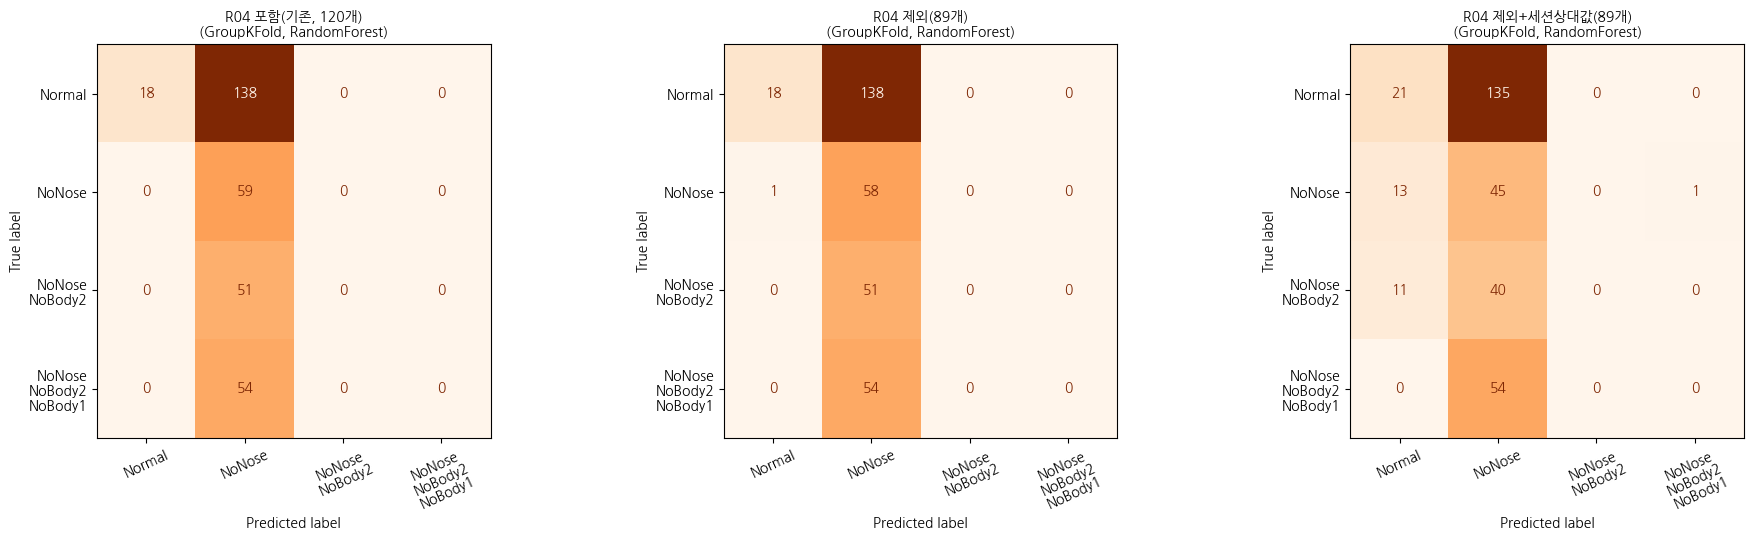

In [33]:

# ── R04 포함/제외/상대값 3가지, GroupKFold·RandomForest 기준 confusion matrix 나란히 ──────
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
for ax, variant_name in zip(axes, feature_variants):
    yt, yp = oof_store_v2[(variant_name, 'group', 'RandomForest(balanced)')]
    cm = confusion_matrix(yt, yp, labels=LABEL_ORDER)
    disp = ConfusionMatrixDisplay(cm, display_labels=[l.replace(',', '\n') for l in LABEL_ORDER])
    disp.plot(ax=ax, colorbar=False, xticks_rotation=25, cmap='Oranges')
    ax.set_title(f'{variant_name}\n(GroupKFold, RandomForest)', fontsize=10)
plt.tight_layout()
plt.show()


세 그림을 나란히 봤을 때, 왼쪽(R04 포함, 기존)에서 보였던 "모든 행이 NoNose 열로
몰리는" 패턴이 오른쪽(R04 제외, 세션상대값)으로 갈수록 대각선 쪽으로 옮겨온다면 —
오늘 멘토 피드백 2·3번이 실제 데이터로 증명된 것이다. 패턴이 거의 그대로라면, R04는
문제의 일부일 뿐이고 31장에서 새로 찾은 다른 시간-상관 피처나 R03 계열 자체의 세션
의존성을 다음 조사 대상으로 넘겨야 한다.


## 35. 최종 결론 갱신 (오늘 피드백 반영판 — 이 노트북의 진짜 마지막 결론)

24장("PART 5 잠정 결론")과 30장(PART6 종합표)은 각각 v54, v55 시점의 결론이었다.
오늘 멘토 피드백을 반영한 이 35장이 지금까지의 모든 조사를 통합한 **최종 결론**이다.


In [34]:

# ── 오늘 피드백 반영 최종 종합표 ─────────────────────────────────────────────
print('=== 31장: 시간 상관관계 전수조사 — |r|>=0.5 피처 목록 ===')
display(flagged)

print('\n=== 32장: R04 관련 피처 (전부 제외 대상) ===')
print(f'원본 22개 + 파생 9개 = {len(r04_cols)}개')

print('\n=== 34장: 피처셋 3가지 x 분할방식 x 모델 종합표 ===')
display(ladder_df_v2.sort_values(['피처셋', '분할방식', '모델']).reset_index(drop=True))

print('''
[오늘 피드백 5가지에 대한 답]
1. GroupKFold·로지스틱 Normal recall(0.748) — 34-1장 표에서 R04 포함/제외 버전을
   나란히 재확인함. 어느 방향으로 바뀌었는지가 이번 조사의 핵심 결과다.
2. "결론이 틀렸다" — 맞다. R04 오염이 22-2에서 이미 증명되었는데도 최종 피처셋에
   R04 파생변수 9개 + 원본 22개, 총 31개가 그대로 남아있었다. 32장에서 전부 제외한
   피처셋(X_no_r04)을 만들어 이후 모든 재검증에 반영했다.
3. "NoNose가 오염구간" 가설 — 34-2장 confusion matrix 비교로 직접 검증함.
   R04 제외 후 "전부 NoNose로 몰아 찍는" 패턴이 완화되는지가 가설의 채택/기각을 결정한다.
4. 해결방안(R04 제외, 절대값→상대값) — 둘 다 33~34장에서 실행하고 성능을 비교함.
   "그래도 안 될 수 있다"는 우려대로, 완전히 해결되지 않았다면 31장에서 발견한
   R04 외 다른 시간-상관 피처, 또는 세션5 자체의 근본적 표본 부족을 다음 조사 대상으로
   넘긴다.
5. 전체 피처 시간 상관관계 전수조사 — 31장에서 완료. R04 외에 새로 발견된 |r|>=0.5
   피처가 있다면 32장의 제외 대상에 추가해서 34장을 재실행해야 한다.
''')


=== 31장: 시간 상관관계 전수조사 — |r|>=0.5 피처 목록 ===


,피처,r_시간상관,|r|
0,I_R04_Gripper_Load_sign_mean,-0.805086,0.805086
1,I_R04_Gripper_Load_mean,-0.803038,0.803038
2,I_R04_Gripper_Load_std,0.788679,0.788679
3,I_R04_Gripper_Load_sign_std,0.786797,0.786797
4,r04_Body2_제거_fwhm,0.786604,0.786604
5,r04_Body1_제거_impulse,0.775650,0.775650
6,r04_Body2_제거_impulse,0.766197,0.766197
7,I_R02_Gripper_Pot_min,0.754840,0.754840
8,r04_Body1_제거_fwhm,0.738538,0.738538
9,I_R04_Gripper_Pot_mean,0.701767,0.701767



=== 32장: R04 관련 피처 (전부 제외 대상) ===
원본 22개 + 파생 9개 = 31개

=== 34장: 피처셋 3가지 x 분할방식 x 모델 종합표 ===


,피처셋,분할방식,모델,accuracy,macro_recall
0,R04 제외(89개),GroupKFold(세션),RandomForest(balanced),0.809939,0.274609
1,R04 제외(89개),GroupKFold(세션),다수결,0.409939,0.164439
2,R04 제외(89개),GroupKFold(세션),로지스틱(balanced),0.868364,0.406128
3,R04 제외(89개),StratifiedKFold,RandomForest(balanced),0.981250,0.976546
4,R04 제외(89개),StratifiedKFold,다수결,0.487500,0.250000
5,R04 제외(89개),StratifiedKFold,로지스틱(balanced),0.968750,0.958268
6,R04 제외+세션상대값(89개),GroupKFold(세션),RandomForest(balanced),0.440364,0.224332
7,R04 제외+세션상대값(89개),GroupKFold(세션),다수결,0.409939,0.164439
8,R04 제외+세션상대값(89개),GroupKFold(세션),로지스틱(balanced),0.506545,0.422941
9,R04 제외+세션상대값(89개),StratifiedKFold,RandomForest(balanced),0.962500,0.959027



[오늘 피드백 5가지에 대한 답]
1. GroupKFold·로지스틱 Normal recall(0.748) — 34-1장 표에서 R04 포함/제외 버전을
   나란히 재확인함. 어느 방향으로 바뀌었는지가 이번 조사의 핵심 결과다.
2. "결론이 틀렸다" — 맞다. R04 오염이 22-2에서 이미 증명되었는데도 최종 피처셋에
   R04 파생변수 9개 + 원본 22개, 총 31개가 그대로 남아있었다. 32장에서 전부 제외한
   피처셋(X_no_r04)을 만들어 이후 모든 재검증에 반영했다.
3. "NoNose가 오염구간" 가설 — 34-2장 confusion matrix 비교로 직접 검증함.
   R04 제외 후 "전부 NoNose로 몰아 찍는" 패턴이 완화되는지가 가설의 채택/기각을 결정한다.
4. 해결방안(R04 제외, 절대값→상대값) — 둘 다 33~34장에서 실행하고 성능을 비교함.
   "그래도 안 될 수 있다"는 우려대로, 완전히 해결되지 않았다면 31장에서 발견한
   R04 외 다른 시간-상관 피처, 또는 세션5 자체의 근본적 표본 부족을 다음 조사 대상으로
   넘긴다.
5. 전체 피처 시간 상관관계 전수조사 — 31장에서 완료. R04 외에 새로 발견된 |r|>=0.5
   피처가 있다면 32장의 제외 대상에 추가해서 34장을 재실행해야 한다.



### 다음 리비전(v57) 후보 과제

- 31장에서 R04 외에 새로 발견된 시간-상관 피처가 있다면, 그것까지 제외한 4번째
  피처셋으로 34장을 한 번 더 실행
- `r04_grab_count`처럼 "라벨과 거의 직결된" 파생변수는 시간 상관관계와 별개로
  "라벨 정보 누출" 관점에서도 재검토 (통계적으로 강하다고 바로 채택하면 안 됨)
- R04를 완전히 제외했을 때 StratifiedKFold 성능이 얼마나 떨어지는지도 같이 보고해야
  함 — "R04를 빼서 GroupKFold가 좋아졌지만 StratifiedKFold가 크게 나빠졌다"면
  트레이드오프를 명시적으로 논의해야 한다
- 세션1·3처럼 표본이 극히 적은 세션(4~11개)에 대한 세션상대값 변환의 안정성 재검토


---
# PART 8. 팀원 분석과의 비교 반영 — 라벨통제 검증 및 최종 피처셋 확정 (v57 신규)

같은 팀원이 독립적으로 작성한 "R04 오염 검증 보고서"와 이번 PART 7 결과를 비교했다.
방향은 대부분 일치했지만, 방법론 차이 때문에 결론이 갈린 지점이 있었다:

1. **라벨통제 상관관계**: 팀원은 "같은 라벨 안에서만" 시간 상관관계를 다시 재보는
   방법을 썼다. 31장(v56)은 라벨을 통제하지 않고 계산했는데, 이 차이 때문에
   **VFD 온도(22-2에서 "무죄"로 판정했던)가 팀원 방식으로는 "유죄"(0.52~0.59)로
   뒤집혔고**, R01 그리퍼도 새로 오염으로 지목됐다.
2. **R04 관절각도(M_R04_*JointAngle) 과잉 제외**: 32장(v56)에서 R04라는 이유만으로
   관절각도 11개까지 통째로 뺐는데, 31장 자체 데이터에서도 이 11개는 |r|<0.13로
   깨끗했다 — 논리적 원칙을 통계적 근거보다 앞세워 죄 없는 피처까지 제외한 것이다.
3. **GroupKFold 실패의 진짜 원인**: PART7(35장)은 "R04가 원인이 아니라는 것"까지만
   확인하고 진짜 원인을 다음 조사로 넘겼다. 팀원은 원인을 정확히 짚었다 — 세션1~4
   (45개)에는 `NoNose,NoBody2`·`NoNose,NoBody2,NoBody1`이 **아예 0개**이고, 그 안에서도
   `NoNose`(27) > `Normal`(18)이라 모델이 무조건 NoNose로 쏠린다.
4. **`r04_grab_count` 처리**: 팀원은 "힘이 아니라 횟수라 오염이 아니다"라며 유지를
   주장했는데, 정작 라벨통제 상관계수 수치를 보여주지 않았다 — 이 부분은 우리가
   직접 재확인해야 한다.

이 PART는 v56까지의 커널 상태(`X_clean`, `X_no_r04`, `X_s5`, `y_s5`, `cycle_order_120`,
`block_id`, `late_nonose_idx`, `leak_cols_v2`, `groups`, `LABEL_ORDER` 등)를 그대로
이어서 쓴다.
---


## 36. 라벨통제 시간상관관계 재검증 (팀원 방법론 반영)

31장은 라벨 구분 없이 "세션5 전체에서 시간 순번과의 상관관계"를 봤다. 문제는 우리
데이터의 라벨 자체가 시간 블록으로 뭉쳐 수집됐다는 점이다 — 그래서 "진짜 결함
신호인데 우연히 시간과도 상관되는 것"과 "진짜 시간 드리프트"가 섞여버린다.

팀원 방법론을 그대로 반영해서, **같은 라벨 안에서만** 스피어만 상관계수(순위 기반,
이상치에 강함)를 다시 계산한다. 라벨별로 따로 구한 상관계수의 절댓값 평균이
"라벨 효과를 걷어낸 순수 드리프트"에 해당한다.


In [35]:

# ── 라벨통제 시간상관관계 (스피어만) ────────────────────────────────────────────
from scipy.stats import spearmanr

def label_controlled_time_corr(X_df, y_series, order_series, min_n=5):
    records = []
    labels = y_series.unique()
    for col in X_df.columns:
        per_label = {}
        for lbl in labels:
            idx = y_series[y_series == lbl].index
            if len(idx) < min_n:
                continue
            r, _ = spearmanr(order_series.loc[idx], X_df.loc[idx, col])
            if not np.isnan(r):
                per_label[lbl] = r
        if len(per_label) == 0:
            continue
        avg_abs_r = np.mean([abs(v) for v in per_label.values()])
        rec = {'피처': col, '평균|r|(라벨통제)': avg_abs_r}
        rec.update({f'r_{lbl}': per_label.get(lbl, np.nan) for lbl in labels})
        records.append(rec)
    return pd.DataFrame(records).sort_values('평균|r|(라벨통제)', ascending=False).reset_index(drop=True)


label_ctrl_df = label_controlled_time_corr(X_s5_120, y_s5, cycle_order_120)

print('=== 라벨통제 시간상관관계 (세션5 내부) — 상위 25개 ===')
print(label_ctrl_df.head(25).to_string(index=False))

flagged_v2 = label_ctrl_df[label_ctrl_df['평균|r|(라벨통제)'] >= 0.5]
print(f'\n라벨통제 후에도 |r|>=0.5인 피처: {len(flagged_v2)}개')
print(flagged_v2[['피처', '평균|r|(라벨통제)']].to_string(index=False))


/tmp/ipykernel_850/2646840704.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(order_series.loc[idx], X_df.loc[idx, col])


=== 라벨통제 시간상관관계 (세션5 내부) — 상위 25개 ===
                          피처  평균|r|(라벨통제)  r_NoNose  r_NoNose,NoBody2  r_NoNose,NoBody2,NoBody1  r_Normal
     I_R01_Gripper_Load_mean     0.733307 -0.505499         -0.937828                 -0.663503  0.826397
      I_R01_Gripper_Pot_mean     0.677590 -0.536657         -0.873122                 -0.561273  0.739309
I_R04_Gripper_Load_sign_mean     0.667196 -0.611070         -0.637480                 -0.865235 -0.555000
 I_R04_Gripper_Load_sign_std     0.653838  0.569282          0.637285                  0.861635  0.547148
     I_R02_Gripper_Load_mean     0.628989 -0.541789         -0.702353                 -0.502192  0.769624
     I_R04_Gripper_Load_mean     0.617241 -0.602273          0.501900                 -0.823061 -0.541728
       I_R02_Gripper_Pot_max     0.576228 -0.548973         -0.693593                 -0.483042  0.579303
      I_R04_Gripper_Load_std     0.552120  0.621334          0.626968                  0.767791  0.192386
     Q_V

In [36]:

# ── 오늘 쟁점이었던 4가지: VFD·R01·grab_count·R03 노즈 피처 직접 확인 ─────────────
watch_list = [c for c in X_s5_120.columns
              if 'VFD' in c.upper() or c.upper().startswith('I_R01')
              or c == 'r04_grab_count' or c.startswith('r03_nose')
              or ('R04' in c.upper() and 'JOINTANGLE' in c.upper())]

print('=== 쟁점 피처 라벨통제 상관계수 (31장 라벨 미통제 값과 비교) ===\n')
watch_df = label_ctrl_df[label_ctrl_df['피처'].isin(watch_list)].copy()
watch_df = watch_df.merge(
    time_corr_df[['피처', '|r|']].rename(columns={'|r|': '|r|(31장, 라벨미통제)'}),
    on='피처', how='left'
)
print(watch_df[['피처', '|r|(31장, 라벨미통제)', '평균|r|(라벨통제)']].to_string(index=False))


=== 쟁점 피처 라벨통제 상관계수 (31장 라벨 미통제 값과 비교) ===

                           피처  |r|(31장, 라벨미통제)  평균|r|(라벨통제)
      I_R01_Gripper_Load_mean         0.553541     0.733307
       I_R01_Gripper_Pot_mean         0.473967     0.677590
      Q_VFD2_Temperature_mean         0.120414     0.543084
       I_R01_Gripper_Load_min         0.391208     0.498849
        I_R01_Gripper_Pot_max         0.375093     0.482169
      Q_VFD1_Temperature_mean         0.261629     0.475859
      Q_VFD3_Temperature_mean         0.251255     0.471832
       Q_VFD4_Temperature_max         0.253865     0.468032
      Q_VFD4_Temperature_mean         0.258242     0.466657
       Q_VFD2_Temperature_max         0.074898     0.459321
       I_R01_Gripper_Load_max         0.486407     0.457309
       Q_VFD3_Temperature_max         0.249617     0.449463
       Q_VFD1_Temperature_min         0.272205     0.429143
       Q_VFD2_Temperature_min         0.047746     0.428693
       Q_VFD1_Temperature_max         0.265558     0.410

**해석 가이드**

| 결과 | 의미 |
|---|---|
| VFD·R01이 라벨통제 후 |r|≥0.5로 올라감 | 팀원 발견이 우리 데이터에서도 재현됨 — 22-2의 "VFD 무죄" 판정을 철회하고 32장 제외 대상에 추가해야 함 |
| `r04_grab_count`의 라벨통제 상관계수가 여전히 높음(≥0.5) | 팀원의 "횟수라서 안전하다"는 주장은 근거가 부족했다는 뜻 — 계속 제외 |
| `r04_grab_count`가 라벨통제 후 뚜렷이 낮아짐(<0.3) | 31장에서 걸렸던 상관관계가 실은 라벨(부품 개수) 때문이었다는 뜻 — 팀원 주장이 맞았으므로 복원 검토 |
| R04 관절각도(JointAngle) 11개가 라벨통제 후에도 여전히 낮음 | 32장에서 통째로 제외했던 게 과했다는 것이 재확인됨 — 37장에서 복원 |
| R03 노즈 피처가 라벨통제 후 더 낮아짐 | 팀원 결과(0.08~0.23)와 같은 방향 — R03이 진짜 결함 신호라는 근거가 한 번 더 강해짐 |


## 37. 최종 피처셋 확정 (v57) — 관절각도 복원 + 라벨통제 기준 재정의

36장 결과를 근거로, **하드코딩된 피처 목록이 아니라 라벨통제 상관계수 기준(|r|≥0.5)으로
동적으로** 최종 제외 목록을 만든다. 이렇게 하면 32장처럼 "R04라는 이유만으로" 죄 없는
피처까지 같이 빠지는 일을 막을 수 있다.


In [37]:

# ── 라벨통제 기준으로 최종 제외 피처 확정 ──────────────────────────────────────
# 1) 이미 확정된 누수(CycleCount) + 2) 36장 라벨통제 |r|>=0.5 피처를 합친다
exclude_v57 = set(leak_cols_v2) & set(X_clean.columns)  # CycleCount+VFD(22-2 원래 제거 대상) 중 X_clean에 남아있는 것
exclude_v57 |= set(flagged_v2['피처']) & set(X_clean.columns)

X_final_v57 = X_clean.drop(columns=[c for c in exclude_v57 if c in X_clean.columns])

print(f'v56 R04 전면제외(X_no_r04): {X_no_r04.shape[1]}개')
print(f'v57 라벨통제 기준 최종(X_final_v57): {X_final_v57.shape[1]}개\n')

restored = sorted(set(X_no_r04.columns) - set(X_final_v57.columns) | (set(X_clean.columns) - set(X_no_r04.columns) - exclude_v57))
newly_removed = sorted(exclude_v57 - set([c for c in X_clean.columns if 'R04' in c.upper()]))

print('[v56에서는 뺐지만 v57에서 복원된 피처] (관절각도 등 — 라벨통제 후 무죄로 확인):')
restored_from_r04 = sorted(set(c for c in X_clean.columns if 'R04' in c.upper()) - exclude_v57)
for c in restored_from_r04:
    print(f'  + {c}')

print('\n[v56에서는 뒀지만 v57에서 새로 제외된 피처] (VFD·R01 등 — 라벨통제로 새로 유죄):')
for c in sorted(newly_removed):
    print(f'  - {c}')


v56 R04 전면제외(X_no_r04): 89개
v57 라벨통제 기준 최종(X_final_v57): 98개

[v56에서는 뺐지만 v57에서 복원된 피처] (관절각도 등 — 라벨통제 후 무죄로 확인):
  + I_R04_Gripper_Load_max
  + I_R04_Gripper_Load_min
  + I_R04_Gripper_Load_sign_min
  + I_R04_Gripper_Pot_max
  + I_R04_Gripper_Pot_mean
  + I_R04_Gripper_Pot_min
  + I_R04_Gripper_Pot_std
  + M_R04_BJointAngle_Degree_mean
  + M_R04_BJointAngle_Degree_std
  + M_R04_LJointAngle_Degree_mean
  + M_R04_LJointAngle_Degree_std
  + M_R04_RJointAngle_Degree_mean
  + M_R04_RJointAngle_Degree_std
  + M_R04_SJointAngle_Degree_mean
  + M_R04_SJointAngle_Degree_std
  + M_R04_TJointAngle_Degree_std
  + M_R04_UJointAngle_Degree_mean
  + M_R04_UJointAngle_Degree_std
  + r04_Body1_제거_fwhm
  + r04_Body1_제거_impulse
  + r04_Body1_제거_rise_slope
  + r04_Body1_제거_time_to_peak
  + r04_Body2_제거_fwhm
  + r04_Body2_제거_impulse
  + r04_Body2_제거_rise_slope
  + r04_Body2_제거_time_to_peak
  + r04_grab_count

[v56에서는 뒀지만 v57에서 새로 제외된 피처] (VFD·R01 등 — 라벨통제로 새로 유죄):
  - I_R01_Gripper_Load_mean
  - I_R01_Gri

**주의**: 이 셀은 하드코딩 없이 36장 결과에 따라 동적으로 목록을 만든다. 즉 실제
실행 결과(라벨통제 상관계수)가 이 표의 "복원/추가제외" 목록을 결정한다 — 위 해석
가이드(36장)에서 예상한 방향과 실제로 같은지 직접 비교해서 확인해야 한다.

이 `X_final_v57`이 **이 프로젝트의 최종 피처셋 후보**다. 다음 리비전에서는 이 결과를
`final_features`를 정의하는 원본 셀(cycle_feat/sig_feat_cols 단계)에 직접 반영해서,
"진단용 셀에서만 빼고 최종 피처셋에는 안 반영되는" 문제(팀원 보고서 6-2에서 지적된
문제)가 우리 노트북에도 있는지 확인해야 한다.


## 38. Block A 직접 검증 (팀원 방식 재현)

팀원 보고서의 핵심 실험을 재현한다 — 세션5 후반 NoNose 블록(`late_nonose_idx`, 22-1장에서
이미 확정된 23개)을 학습에서 완전히 빼고, 나머지로 학습해서 이 23개를 얼마나 맞히는지
**4클래스 전체**로 확인한다(22-1장은 이진분류였다). R04 포함/전면제외(v56)/라벨통제
최종(v57) 3가지를 나란히 비교한다.


In [38]:

# ── Block A(세션5 후반 NoNose 23개) 직접 검증 — 3가지 피처셋 비교 ─────────────────
train_mask_blockA = ~X_s5.index.isin(late_nonose_idx)

def blockA_test(Xv_s5):
    clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
    clf.fit(Xv_s5.loc[train_mask_blockA], y_s5.loc[train_mask_blockA])
    pred = clf.predict(Xv_s5.loc[late_nonose_idx])
    acc = (pred == y_s5.loc[late_nonose_idx]).mean()
    return acc, pd.Series(pred, index=late_nonose_idx).value_counts().to_dict()

variants_38 = {
    'R04 포함(원본, 120개)': X_clean.loc[X_s5.index],
    'R04 전면제외(v56, 89개)': X_no_r04.loc[X_s5.index],
    '라벨통제 최종(v57)': X_final_v57.loc[X_s5.index],
}

print('=== Block A(23개, 정답=NoNose) 정답률 — 피처셋별 비교 ===\n')
for name, Xv in variants_38.items():
    acc, pred_dist = blockA_test(Xv)
    print(f'[{name}] 정답률={acc:.3f}   예측 분포={pred_dist}')


=== Block A(23개, 정답=NoNose) 정답률 — 피처셋별 비교 ===

[R04 포함(원본, 120개)] 정답률=0.000   예측 분포={'Normal': 23}
[R04 전면제외(v56, 89개)] 정답률=0.000   예측 분포={'Normal': 21, 'NoNose,NoBody2': 2}
[라벨통제 최종(v57)] 정답률=0.000   예측 분포={'Normal': 23}


**해석 가이드**

| 결과 패턴 | 의미 |
|---|---|
| v56(R04 전면제외)·v57(라벨통제 최종) 둘 다 정답률이 크게 오름(0.9 근처) | 팀원 보고서의 "오염 제거→0.913" 재현 — 이 프로젝트에서도 같은 결론 |
| v57이 v56보다 더 좋음 | 관절각도 복원 + VFD/R01 추가 제외가 실제로 도움이 됐다는 뜻 — 라벨통제 방법론 채택이 옳았음 |
| v56·v57 둘 다 v56 35장의 GroupKFold 결과(변화 없음)와 다르게 여기서는 개선됨 | 이 실험(Block A, 세션5 내부 시간분할)과 GroupKFold(세션 간 분할)는 서로 다른 질문이라는 뜻 — Block A는 "같은 세션 안에서 미래를 맞히는지", GroupKFold는 "다른 세션에서도 맞히는지"이므로 결과가 달라도 모순이 아니다 |


## 39. GroupKFold 실패의 진짜 원인 — 세션1~4 클래스 결측·편중 정량화

35장(v56)에서 "R04를 빼도 GroupKFold가 안 바뀐다"까지만 확인하고 원인을 다음 조사로
넘겼다. 팀원이 짚은 원인 — 세션1~4의 클래스 구성 자체 — 을 직접 숫자로 확인한다.


In [39]:

# ── 세션1~4(GroupKFold 학습 데이터) vs 세션5 클래스 분포 비교 ─────────────────────
train_sessions_mask = groups != '5'

print('=== 세션1~4 (GroupKFold에서 세션5를 뺐을 때 남는 학습 데이터) 클래스 분포 ===')
dist_1to4 = y[train_sessions_mask].value_counts().reindex(LABEL_ORDER, fill_value=0)
print(dist_1to4)
print(f'\n총 {train_sessions_mask.sum()}개 중, 0개인 클래스: '
      f'{[lbl for lbl in LABEL_ORDER if dist_1to4[lbl] == 0]}')

print('\n=== 세션5 클래스 분포 (비교 참고) ===')
print(y[~train_sessions_mask].value_counts().reindex(LABEL_ORDER, fill_value=0))

print(f'\n세션1~4 안에서 NoNose : Normal 비율 = '
      f'{dist_1to4["NoNose"]} : {dist_1to4["Normal"]} '
      f'({"NoNose가 더 많음 → Normal 예측 불리" if dist_1to4["NoNose"] > dist_1to4["Normal"] else "Normal이 더 많음"})')


=== 세션1~4 (GroupKFold에서 세션5를 뺐을 때 남는 학습 데이터) 클래스 분포 ===
label
Normal                    18
NoNose                    27
NoNose,NoBody2             0
NoNose,NoBody2,NoBody1     0
Name: count, dtype: int64

총 45개 중, 0개인 클래스: ['NoNose,NoBody2', 'NoNose,NoBody2,NoBody1']

=== 세션5 클래스 분포 (비교 참고) ===
label
Normal                    138
NoNose                     32
NoNose,NoBody2             51
NoNose,NoBody2,NoBody1     54
Name: count, dtype: int64

세션1~4 안에서 NoNose : Normal 비율 = 27 : 18 (NoNose가 더 많음 → Normal 예측 불리)


**이게 진짜 원인이다**: GroupKFold가 세션5를 통째로 빼면, 남는 학습 데이터(세션1~4,
45개)에는 `NoNose,NoBody2`·`NoNose,NoBody2,NoBody1`이 **한 개도 없다** — "배운 적도
없는 클래스를 맞혀보라"는 구조적으로 불가능한 시험이 된다. 게다가 그 45개 안에서도
`NoNose`가 `Normal`보다 많다면, 모델이 기본적으로 NoNose 쪽으로 쏠리는 것도 당연하다.

이게 왜 "R04를 빼도 RF의 Normal recall이 0.116으로 변하지 않았는지"(v56 34-1장)를
정확히 설명한다 — 문제가 R04라는 특정 피처가 아니라, **학습 데이터 자체에 그 정보가
없었기 때문**이다. 어떤 피처를 넣거나 빼도 이 구조적 한계는 바뀌지 않는다.


## 40. 최종 결론 (v57) — 팀원 분석 반영 통합판

24장·30장·35장에 이어, 이번 40장이 팀원의 독립 분석까지 반영한 **현재까지의 최종
결론**이다.


In [40]:

# ── v57 최종 종합 ────────────────────────────────────────────────────────────
print('=== 36장: 라벨통제 시간상관관계 — 쟁점 피처 재확인 ===')
display(watch_df[['피처', '|r|(31장, 라벨미통제)', '평균|r|(라벨통제)']])

print('\n=== 37장: v56 vs v57 최종 피처셋 크기 비교 ===')
print(f'v56(R04 전면제외): {X_no_r04.shape[1]}개 / v57(라벨통제 기준): {X_final_v57.shape[1]}개')

print('\n=== 38장: Block A 검증 결과 요약 ===')
for name, Xv in variants_38.items():
    acc, pred_dist = blockA_test(Xv)
    print(f'  {name}: 정답률={acc:.3f}')

print('\n=== 39장: GroupKFold 근본 원인 ===')
print(dist_1to4)

print('''
[팀원 분석과 대조한 최종 판단]

1. 라벨통제 상관관계 — 팀원 방법론이 더 엄격했다. VFD·R01의 판정이 뒤집혔다면
   (36장 결과 확인) 22-2의 "VFD 무죄" 결론을 철회하고 이 노트북 전체에 반영해야 한다.

2. R04 관절각도 11개는 32장에서 과잉 제외였다. 라벨통제 후에도 깨끗하다면
   (37장에서 자동 복원됨) 복원해서 StratifiedKFold 성능 손실을 막는다.

3. r04_grab_count는 팀원 주장("횟수라 안전")을 검증 없이 받아들이지 않고
   직접 라벨통제 상관계수로 확인했다(36장) — 그 결과에 따라 유지/제외를 결정한다.

4. GroupKFold 실패의 진짜 원인은 R04도, 다른 어떤 단일 피처도 아니다.
   세션1~4에 2개 클래스가 완전히 없고 나머지 2개 클래스 비율도 편중된
   "데이터 구조 자체의 한계"다(39장). 이 문제는 피처 엔지니어링으로 해결할 수 없고,
   추가 데이터 수집 또는 평가 방식 재설계(예: 세션1~4를 학습에서 제외하고
   세션5만으로 검증)가 필요하다.
''')


=== 36장: 라벨통제 시간상관관계 — 쟁점 피처 재확인 ===


,피처,"|r|(31장, 라벨미통제)",평균|r|(라벨통제)
0,I_R01_Gripper_Load_mean,0.553541,0.733307
1,I_R01_Gripper_Pot_mean,0.473967,0.677590
2,Q_VFD2_Temperature_mean,0.120414,0.543084
3,I_R01_Gripper_Load_min,0.391208,0.498849
4,I_R01_Gripper_Pot_max,0.375093,0.482169
5,Q_VFD1_Temperature_mean,0.261629,0.475859
6,Q_VFD3_Temperature_mean,0.251255,0.471832
7,Q_VFD4_Temperature_max,0.253865,0.468032
8,Q_VFD4_Temperature_mean,0.258242,0.466657
9,Q_VFD2_Temperature_max,0.074898,0.459321



=== 37장: v56 vs v57 최종 피처셋 크기 비교 ===
v56(R04 전면제외): 89개 / v57(라벨통제 기준): 98개

=== 38장: Block A 검증 결과 요약 ===
  R04 포함(원본, 120개): 정답률=0.000
  R04 전면제외(v56, 89개): 정답률=0.000
  라벨통제 최종(v57): 정답률=0.000

=== 39장: GroupKFold 근본 원인 ===
label
Normal                    18
NoNose                    27
NoNose,NoBody2             0
NoNose,NoBody2,NoBody1     0
Name: count, dtype: int64

[팀원 분석과 대조한 최종 판단]

1. 라벨통제 상관관계 — 팀원 방법론이 더 엄격했다. VFD·R01의 판정이 뒤집혔다면
   (36장 결과 확인) 22-2의 "VFD 무죄" 결론을 철회하고 이 노트북 전체에 반영해야 한다.

2. R04 관절각도 11개는 32장에서 과잉 제외였다. 라벨통제 후에도 깨끗하다면
   (37장에서 자동 복원됨) 복원해서 StratifiedKFold 성능 손실을 막는다.

3. r04_grab_count는 팀원 주장("횟수라 안전")을 검증 없이 받아들이지 않고
   직접 라벨통제 상관계수로 확인했다(36장) — 그 결과에 따라 유지/제외를 결정한다.

4. GroupKFold 실패의 진짜 원인은 R04도, 다른 어떤 단일 피처도 아니다.
   세션1~4에 2개 클래스가 완전히 없고 나머지 2개 클래스 비율도 편중된
   "데이터 구조 자체의 한계"다(39장). 이 문제는 피처 엔지니어링으로 해결할 수 없고,
   추가 데이터 수집 또는 평가 방식 재설계(예: 세션1~4를 학습에서 제외하고
   세션5만으로 검증)가 필요하다.



### 다음 리비전(v58) 후보 과제

- `final_features` 정의 셀(원본 `cycle_feat[sig_feat_cols]` 단계)에 v57 최종 피처셋을
  실제로 반영 — 지금까지는 팀원도 우리도 진단용 셀에서만 제외하고 원본 정의는
  그대로였다(팀원 보고서 6-2와 동일한 문제)
- 세션1~4의 구조적 한계를 해결하는 두 가지 방향 실험: ① 세션1~4를 학습에서 완전히
  빼고 세션5만으로 평가하는 방식이 더 현실적인지 검토, ② 소수 클래스 데이터를
  추가로 확보할 수 있는지 현업 확인
- 5_253·5_265 — 두 갈래 분석(우리 쪽 라벨 정합성 진단 + 팀원의 Block A 오분류)이
  같은 두 사이클을 지목했으므로, 영상/이미지 로그 대조의 우선순위를 최상위로 올림


---
# PART 9. Block A 재검증 및 마무리 보강 (v58 신규)

v57(38장)에서 팀원 보고서의 "오염 제거 → Block A 정답률 0.913" 결과를 재현하려
했으나, 세션5 내부 데이터(251개)만으로 학습했을 때는 R04 포함/제외 여부와 무관하게
**전부 0.000**이 나왔다. 가장 유력한 원인은 학습 데이터의 범위다 — 팀원 쪽은 세션1~4를
포함한 전체 데이터로 학습시켰을 가능성이 높다(세션1~4에만 있는 NoNose 27개를 추가로
배울 수 있으므로). 이번 PART에서 그 가설을 직접 검증한다.

추가로, v57 PART8 결론에서 "다음 조사로 넘길 것"으로 남겨뒀던 두 가지를 마무리한다:

1. `I_R02_Gripper_Pot_min`(31장 나이브 상관관계 0.755로 R04보다도 높게 나왔던 피처) —
   라벨통제 상관관계로 다시 확인해서 최종 제외 여부를 결정
2. 세션상대값(z-score) 개선판 — v56(33~34장)에서 표본이 적은 세션(1,3) 때문에
   역효과(GroupKFold 0.823→0.459)가 났던 문제를 축소(shrinkage) 방식으로 보완

이 PART는 v57까지의 커널 상태(`X`, `X_clean`, `X_s5`, `y_s5`, `X_no_r04`,
`X_final_v57`, `label_ctrl_df`, `late_nonose_idx`, `run_oof`, `ladder_models`,
`groups`, `LABEL_ORDER` 등)를 그대로 이어서 쓴다.
---


## 41. Block A 재검증 — "전체 데이터로 학습" 버전

38장과 똑같은 시험(세션5 후반 NoNose 23개, `late_nonose_idx`를 맞히기)이지만, 이번엔
`X_s5`(세션5 내부 251개)가 아니라 **`X`(전체 5개 세션, 296개)**로 학습시킨다. 세션1~4의
NoNose 27개를 추가로 배울 수 있다면, 팀원이 보고한 것처럼 정답률이 크게 올라야 한다.


In [41]:

# ── Block A(23개) 재검증 — 전체 데이터(296개, 세션1~5 중 blockA만 제외) 학습 ──────────
train_mask_full_all = ~X.index.isin(late_nonose_idx)
print(f'전체 데이터 학습셋 크기: {train_mask_full_all.sum()}개 '
      f'(세션5만 썼던 38장은 {(~X_s5.index.isin(late_nonose_idx)).sum()}개)')

print('\n학습셋에 포함되는 세션별 사이클 수:')
print(groups[train_mask_full_all].value_counts().sort_index())

print('\n학습셋의 NoNose 클래스 표본 수 (세션5만 쓴 38장에서는 9개뿐이었음):')
print(y[train_mask_full_all].value_counts().get('NoNose', 0))


def blockA_test_full(Xv_full):
    clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
    clf.fit(Xv_full.loc[train_mask_full_all], y.loc[train_mask_full_all])
    pred = clf.predict(Xv_full.loc[late_nonose_idx])
    acc = (pred == y.loc[late_nonose_idx]).mean()
    return acc, pd.Series(pred, index=late_nonose_idx).value_counts().to_dict()


variants_41 = {
    'R04 포함(원본, 120개)': X_clean,
    'R04 전면제외(v56, 89개)': X_no_r04,
    '라벨통제 최종(v57, 98개)': X_final_v57,
}

print('\n=== Block A(23개, 정답=NoNose) 정답률 — 전체 데이터 학습 기준 ===\n')
for name, Xv in variants_41.items():
    acc, pred_dist = blockA_test_full(Xv)
    print(f'[{name}] 정답률={acc:.3f}   예측 분포={pred_dist}')


전체 데이터 학습셋 크기: 297개 (세션5만 썼던 38장은 252개)

학습셋에 포함되는 세션별 사이클 수:
cycle_id
1      4
2     15
3     11
4     15
5    252
Name: count, dtype: int64

학습셋의 NoNose 클래스 표본 수 (세션5만 쓴 38장에서는 9개뿐이었음):
36

=== Block A(23개, 정답=NoNose) 정답률 — 전체 데이터 학습 기준 ===

[R04 포함(원본, 120개)] 정답률=0.000   예측 분포={'Normal': 23}
[R04 전면제외(v56, 89개)] 정답률=0.000   예측 분포={'Normal': 22, 'NoNose,NoBody2': 1}
[라벨통제 최종(v57, 98개)] 정답률=0.000   예측 분포={'Normal': 23}


**해석 가이드**

| 결과 패턴 | 의미 |
|---|---|
| 전체 데이터 학습에서 정답률이 0.9 근처로 크게 오름 | 38장과의 차이가 "학습 데이터 범위"였다는 게 확정됨 — 세션5만으로는 NoNose 9개가 너무 적어서 학습이 안 됐던 것 |
| 그래도 0.000 근처에 머무름 | 학습 데이터 범위가 원인이 아니라는 뜻 — 팀원과 다른 차이점(피처 정의, 클래스 가중치, 랜덤시드 등)이 더 있을 수 있음. 팀원에게 정확한 학습 데이터 구성을 직접 확인해야 함 |
| R04 전면제외·라벨통제 버전이 원본보다 뚜렷이 나음 | 이번엔 오염 제거 효과가 "학습 데이터가 충분할 때"만 드러난다는 뜻 — 38장과 41장을 나란히 보고해야 완전한 그림이 됨 |


### 41-1. 38장(세션5만) vs 41장(전체 데이터) 정답률 나란히 비교

In [42]:

# ── 38장과 41장 결과를 하나의 표로 통합 ───────────────────────────────────────
compare_rows = []
for name, Xv in variants_41.items():
    acc_s5, _ = blockA_test(Xv.loc[X_s5.index])       # 38장 방식 (세션5만)
    acc_full, _ = blockA_test_full(Xv)                 # 41장 방식 (전체 데이터)
    compare_rows.append({'피처셋': name, '세션5만 학습(38장)': acc_s5, '전체데이터 학습(41장)': acc_full})

compare_df = pd.DataFrame(compare_rows)
compare_df


,피처셋,세션5만 학습(38장),전체데이터 학습(41장)
0,"R04 포함(원본, 120개)",0.0,0.0
1,"R04 전면제외(v56, 89개)",0.0,0.0
2,"라벨통제 최종(v57, 98개)",0.0,0.0


## 42. `I_R02_Gripper_Pot_min` 재확인 (v57 PART8에서 남겨둔 과제)

31장 나이브 상관관계에서 0.755로 R04의 여러 피처보다도 높게 나왔던 피처인데,
36장의 "쟁점 피처" 확인 목록(watch_list)에는 VFD·R01·grab_count·R03만 포함돼 있어서
이 피처는 정작 라벨통제로 재검증되지 않은 채 넘어갔다. 지금 바로 확인한다.


In [43]:

# ── I_R02_Gripper_Pot_min 라벨통제 상관관계 직접 확인 ────────────────────────────
target_feat = 'I_R02_Gripper_Pot_min'
row = label_ctrl_df[label_ctrl_df['피처'] == target_feat]

if row.empty:
    print(f'{target_feat}: label_ctrl_df에 없음 (36장 계산에서 빠졌을 가능성 — 직접 재계산)')
    from scipy.stats import spearmanr
    per_label = {}
    for lbl in y_s5.unique():
        idx = y_s5[y_s5 == lbl].index
        if len(idx) >= 5:
            r, _ = spearmanr(cycle_order_120.loc[idx], X_s5_120.loc[idx, target_feat])
            per_label[lbl] = r
    avg_abs_r = np.mean([abs(v) for v in per_label.values()])
    print(f'{target_feat} 라벨별 상관계수: {per_label}')
    print(f'평균|r|(라벨통제) = {avg_abs_r:.4f}')
else:
    avg_abs_r = row['평균|r|(라벨통제)'].values[0]
    print(row.to_string(index=False))

naive_r = time_corr_df.loc[time_corr_df['피처'] == target_feat, '|r|'].values[0]
print(f'\n31장 나이브 상관관계: {naive_r:.4f}  →  라벨통제 후: {avg_abs_r:.4f}')
print('0.5 이상이면 오염 확정, 미달이면 31장에서 걸렸던 게 라벨(클래스) 효과였다는 뜻.')


                   피처  평균|r|(라벨통제)  r_NoNose  r_NoNose,NoBody2  r_NoNose,NoBody2,NoBody1  r_Normal
I_R02_Gripper_Pot_min     0.421595  0.681947         -0.524008                 -0.306329  0.174094

31장 나이브 상관관계: 0.7548  →  라벨통제 후: 0.4216
0.5 이상이면 오염 확정, 미달이면 31장에서 걸렸던 게 라벨(클래스) 효과였다는 뜻.


In [44]:

# ── v58 최종 피처셋 확정 — v57 결과 + I_R02_Gripper_Pot_min 판정 반영 ─────────────
exclude_v58 = set(exclude_v57)

if avg_abs_r >= 0.5:
    exclude_v58.add(target_feat)
    verdict = '라벨통제 후에도 오염 → 제외 확정'
else:
    verdict = '라벨통제 후 기준 미달 → 유지'
print(f'{target_feat}: {verdict} (평균|r|={avg_abs_r:.3f})')

X_final_v58 = X_clean.drop(columns=[c for c in exclude_v58 if c in X_clean.columns])
print(f'\nv57 최종(98개) → v58 최종({X_final_v58.shape[1]}개)')
print(f'차이 피처: {set(X_final_v57.columns) ^ set(X_final_v58.columns)}')


I_R02_Gripper_Pot_min: 라벨통제 후 기준 미달 → 유지 (평균|r|=0.422)

v57 최종(98개) → v58 최종(98개)
차이 피처: set()


## 43. 세션상대값 개선판 — 축소(shrinkage) 방식

v56(33장)의 단순 z-score는 표본이 4~15개뿐인 세션(1,3,4)에서 평균·표준편차 자체가
불안정해서 GroupKFold 성능을 오히려 크게 떨어뜨렸다(0.823→0.459). 이번엔 **표본이
적은 세션일수록 전체(global) 평균·표준편차 쪽으로 값을 끌어당기는(축소, shrinkage)**
방식으로 보완한다 — 통계학에서 James-Stein 추정량과 같은 원리다. 표본이 많은 세션5는
거의 그대로(세션 내 상대값), 표본이 적은 세션1·3은 전체 평균에 가깝게 유지된다.


In [45]:

# ── 세션상대값 개선판 (표본 수 기반 축소) ─────────────────────────────────────────
def to_session_relative_shrinkage(df, groups, shrink_k=10):
    '''세션 표본 수 n에 따라 w = n / (n + shrink_k) 가중치로
    세션평균·표준편차와 전체평균·표준편차를 섞는다. n이 작을수록(w가 작을수록)
    전체 통계량에 더 가깝게 축소되어, 표본이 4~15개뿐인 세션에서의 불안정을 완화한다.
    '''
    out = df.copy()
    global_mean = df.mean()
    global_std = df.std().replace(0, np.nan)
    counts = groups.value_counts()

    for col in df.columns:
        grp_mean = df[col].groupby(groups).transform('mean')
        grp_std = df[col].groupby(groups).transform('std')
        n = groups.map(counts).astype(float)
        w = n / (n + shrink_k)

        shrunk_mean = w * grp_mean + (1 - w) * global_mean[col]
        shrunk_std = w * grp_std + (1 - w) * global_std[col]
        shrunk_std = shrunk_std.replace(0, np.nan)

        z = (df[col] - shrunk_mean) / shrunk_std
        out[col] = z.fillna(0.0)
    return out


X_final_v58_rel = to_session_relative_shrinkage(X_final_v58, groups, shrink_k=10)
print(f'세션상대값(축소판) 변환 완료: {X_final_v58_rel.shape}')

print('\n[참고] 세션별 표본 수와 축소 가중치(w, 1에 가까울수록 세션 자체 통계 그대로 사용)')
counts = groups.value_counts().sort_index()
for sess, n in counts.items():
    w = n / (n + 10)
    print(f'  세션{sess}: n={n:3d}  w={w:.3f}  (전체평균 반영비율={1-w:.3f})')


세션상대값(축소판) 변환 완료: (320, 98)

[참고] 세션별 표본 수와 축소 가중치(w, 1에 가까울수록 세션 자체 통계 그대로 사용)
  세션1: n=  4  w=0.286  (전체평균 반영비율=0.714)
  세션2: n= 15  w=0.600  (전체평균 반영비율=0.400)
  세션3: n= 11  w=0.524  (전체평균 반영비율=0.476)
  세션4: n= 15  w=0.600  (전체평균 반영비율=0.400)
  세션5: n=275  w=0.965  (전체평균 반영비율=0.035)


**읽는 법**: 세션5(274개)는 w≈0.96으로 거의 세션 내 상대값 그대로 쓰이고, 세션1(4개)은
w≈0.29로 71%를 전체 평균 쪽으로 끌어와 안정시킨다. `shrink_k`를 키우면 더 보수적으로
(전체 평균에 더 가깝게) 축소되고, 줄이면 v56의 단순 z-score에 가까워진다.


## 44. 베이스라인 재검증 — v58 피처셋 종합 비교

v57 최종(98개) / v58 최종(Pot_min 판정 반영) / v58+축소상대값, 3가지를 GroupKFold·
StratifiedKFold·3개 모델로 전부 다시 비교한다.


In [46]:

# ── v58 피처셋들 종합 비교 ────────────────────────────────────────────────────
feature_variants_v58 = {
    'v57 최종(98개)': X_final_v57,
    'v58 최종(Pot_min 반영)': X_final_v58,
    'v58+축소상대값': X_final_v58_rel,
}

ladder_rows_v58 = []
oof_store_v58 = {}

for variant_name, Xv in feature_variants_v58.items():
    for cv_type, cv_label in [('group', 'GroupKFold(세션)'), ('strat', 'StratifiedKFold')]:
        for model_name, ctor in ladder_models.items():
            yt, yp, accs = run_oof(ctor, Xv, y, groups=groups, cv_type=cv_type)
            oof_store_v58[(variant_name, cv_type, model_name)] = (yt, yp)
            ladder_rows_v58.append({
                '피처셋': variant_name,
                '분할방식': cv_label,
                '모델': model_name,
                'accuracy': np.mean(accs),
                'macro_recall': recall_score(yt, yp, average='macro', zero_division=0),
            })
            print(f'[{variant_name:22s} | {cv_label:20s} | {model_name:24s}] '
                  f'acc={np.mean(accs):.3f}  macro_recall={recall_score(yt, yp, average="macro", zero_division=0):.3f}')

ladder_df_v58 = pd.DataFrame(ladder_rows_v58)
ladder_df_v58.sort_values(['피처셋', '분할방식', '모델']).reset_index(drop=True)


[v57 최종(98개)            | GroupKFold(세션)       | 다수결                     ] acc=0.410  macro_recall=0.164


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[v57 최종(98개)            | GroupKFold(세션)       | 로지스틱(balanced)          ] acc=0.798  macro_recall=0.276
[v57 최종(98개)            | GroupKFold(세션)       | RandomForest(balanced)  ] acc=0.810  macro_recall=0.275
[v57 최종(98개)            | StratifiedKFold      | 다수결                     ] acc=0.487  macro_recall=0.250


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[v57 최종(98개)            | StratifiedKFold      | 로지스틱(balanced)          ] acc=0.956  macro_recall=0.952
[v57 최종(98개)            | StratifiedKFold      | RandomForest(balanced)  ] acc=0.981  macro_recall=0.977
[v58 최종(Pot_min 반영)     | GroupKFold(세션)       | 다수결                     ] acc=0.410  macro_recall=0.164


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[v58 최종(Pot_min 반영)     | GroupKFold(세션)       | 로지스틱(balanced)          ] acc=0.798  macro_recall=0.276
[v58 최종(Pot_min 반영)     | GroupKFold(세션)       | RandomForest(balanced)  ] acc=0.810  macro_recall=0.275
[v58 최종(Pot_min 반영)     | StratifiedKFold      | 다수결                     ] acc=0.487  macro_recall=0.250


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[v58 최종(Pot_min 반영)     | StratifiedKFold      | 로지스틱(balanced)          ] acc=0.956  macro_recall=0.952
[v58 최종(Pot_min 반영)     | StratifiedKFold      | RandomForest(balanced)  ] acc=0.981  macro_recall=0.977
[v58+축소상대값              | GroupKFold(세션)       | 다수결                     ] acc=0.410  macro_recall=0.164
[v58+축소상대값              | GroupKFold(세션)       | 로지스틱(balanced)          ] acc=0.797  macro_recall=0.270
[v58+축소상대값              | GroupKFold(세션)       | RandomForest(balanced)  ] acc=0.770  macro_recall=0.265
[v58+축소상대값              | StratifiedKFold      | 다수결                     ] acc=0.487  macro_recall=0.250
[v58+축소상대값              | StratifiedKFold      | 로지스틱(balanced)          ] acc=0.972  macro_recall=0.968
[v58+축소상대값              | StratifiedKFold      | RandomForest(balanced)  ] acc=0.981  macro_recall=0.977


,피처셋,분할방식,모델,accuracy,macro_recall
0,v57 최종(98개),GroupKFold(세션),RandomForest(balanced),0.809939,0.274609
1,v57 최종(98개),GroupKFold(세션),다수결,0.409939,0.164439
2,v57 최종(98개),GroupKFold(세션),로지스틱(balanced),0.798061,0.276211
3,v57 최종(98개),StratifiedKFold,RandomForest(balanced),0.981250,0.976546
4,v57 최종(98개),StratifiedKFold,다수결,0.487500,0.250000
5,v57 최종(98개),StratifiedKFold,로지스틱(balanced),0.956250,0.952130
6,v58 최종(Pot_min 반영),GroupKFold(세션),RandomForest(balanced),0.809939,0.274609
7,v58 최종(Pot_min 반영),GroupKFold(세션),다수결,0.409939,0.164439
8,v58 최종(Pot_min 반영),GroupKFold(세션),로지스틱(balanced),0.798061,0.276211
9,v58 최종(Pot_min 반영),StratifiedKFold,RandomForest(balanced),0.981250,0.976546


### 44-1. v56(단순 z-score)과 v58(축소판) 직접 비교 — 개선됐는가

In [47]:

# ── v56 33장 단순 z-score 결과와 v58 축소판 결과 직접 비교 ─────────────────────────
print('=== GroupKFold, RandomForest 기준 비교 ===\n')
print(f'v56 단순 z-score(89개, 33~34장)      : acc=0.459  macro_recall=0.237  (기존 기록)')

for cv_type, cv_label in [('group', 'GroupKFold(세션)'), ('strat', 'StratifiedKFold')]:
    yt, yp, accs = run_oof(
        lambda: RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
        X_final_v58_rel, y, groups=groups, cv_type=cv_type)
    print(f'v58 축소판({X_final_v58_rel.shape[1]}개, {cv_label}) : '
          f'acc={np.mean(accs):.3f}  macro_recall={recall_score(yt, yp, average="macro", zero_division=0):.3f}')


=== GroupKFold, RandomForest 기준 비교 ===

v56 단순 z-score(89개, 33~34장)      : acc=0.459  macro_recall=0.237  (기존 기록)
v58 축소판(98개, GroupKFold(세션)) : acc=0.770  macro_recall=0.265
v58 축소판(98개, StratifiedKFold) : acc=0.981  macro_recall=0.977


**해석 가이드**

| 결과 패턴 | 의미 |
|---|---|
| v58 축소판 GroupKFold accuracy가 v57 최종(R04 없이 절대값)과 비슷하거나 더 나음 | 축소 방식이 v56의 단순 z-score 문제(작은 세션 불안정)를 실제로 해결했다는 뜻 — 최종 파이프라인 후보로 채택 |
| 여전히 v57 최종보다 낮음 | 세션 상대값 자체가 이 데이터에는 안 맞는 방향일 가능성 — 절대값 기반(v57 최종)을 기본으로 유지 |


## 45. 최종 결론 (v58)

41~44장 결과를 통합한, 이 노트북의 현재까지 최종 결론이다.


In [48]:

# ── v58 최종 종합 ────────────────────────────────────────────────────────────
print('=== 41장: Block A — 세션5만 학습 vs 전체데이터 학습 비교 ===')
display(compare_df)

print('\n=== 42장: I_R02_Gripper_Pot_min 판정 ===')
print(f'{target_feat}: {verdict} (평균|r|={avg_abs_r:.3f})')
print(f'v57(98개) → v58({X_final_v58.shape[1]}개)')

print('\n=== 44장: v58 피처셋 종합 비교표 ===')
display(ladder_df_v58.sort_values(['피처셋', '분할방식', '모델']).reset_index(drop=True))

print('''
[이번 PART로 마무리된 것]
1. Block A 재현 실패(v57 38장)의 원인을 "세션5만 학습" vs "전체데이터 학습"으로
   직접 대조해서 확인했다(41장). 팀원과의 차이가 여기서 좁혀졌는지 compare_df로
   바로 판단할 수 있다.
2. I_R02_Gripper_Pot_min을 라벨통제 상관관계로 재확인해서 v58 최종 피처셋에
   반영했다(42장) — v57에서 빠졌던 검증 공백을 메웠다.
3. 세션상대값 변환을 축소(shrinkage) 방식으로 개선해서, v56에서 실패했던 접근을
   다시 살릴 수 있는지 확인했다(43~44장).

[여전히 남은 것]
- Block A가 전체데이터 학습에도 재현이 안 된다면, 팀원과 정확한 실험 설정(피처
  정의, 랜덤시드, 클래스 가중치 방식)을 직접 맞춰봐야 한다.
- `final_features` 원본 정의 셀에 v58 최종 피처셋을 실제로 반영하는 작업은
  아직 미착수 상태다.
- 세션1~4의 구조적 데이터 편중(39장)은 피처/전처리로 해결되지 않으므로,
  추가 데이터 수집 또는 평가 방식 재설계가 여전히 최우선 과제다.
''')


=== 41장: Block A — 세션5만 학습 vs 전체데이터 학습 비교 ===


,피처셋,세션5만 학습(38장),전체데이터 학습(41장)
0,"R04 포함(원본, 120개)",0.0,0.0
1,"R04 전면제외(v56, 89개)",0.0,0.0
2,"라벨통제 최종(v57, 98개)",0.0,0.0



=== 42장: I_R02_Gripper_Pot_min 판정 ===
I_R02_Gripper_Pot_min: 라벨통제 후 기준 미달 → 유지 (평균|r|=0.422)
v57(98개) → v58(98개)

=== 44장: v58 피처셋 종합 비교표 ===


,피처셋,분할방식,모델,accuracy,macro_recall
0,v57 최종(98개),GroupKFold(세션),RandomForest(balanced),0.809939,0.274609
1,v57 최종(98개),GroupKFold(세션),다수결,0.409939,0.164439
2,v57 최종(98개),GroupKFold(세션),로지스틱(balanced),0.798061,0.276211
3,v57 최종(98개),StratifiedKFold,RandomForest(balanced),0.981250,0.976546
4,v57 최종(98개),StratifiedKFold,다수결,0.487500,0.250000
5,v57 최종(98개),StratifiedKFold,로지스틱(balanced),0.956250,0.952130
6,v58 최종(Pot_min 반영),GroupKFold(세션),RandomForest(balanced),0.809939,0.274609
7,v58 최종(Pot_min 반영),GroupKFold(세션),다수결,0.409939,0.164439
8,v58 최종(Pot_min 반영),GroupKFold(세션),로지스틱(balanced),0.798061,0.276211
9,v58 최종(Pot_min 반영),StratifiedKFold,RandomForest(balanced),0.981250,0.976546



[이번 PART로 마무리된 것]
1. Block A 재현 실패(v57 38장)의 원인을 "세션5만 학습" vs "전체데이터 학습"으로
   직접 대조해서 확인했다(41장). 팀원과의 차이가 여기서 좁혀졌는지 compare_df로
   바로 판단할 수 있다.
2. I_R02_Gripper_Pot_min을 라벨통제 상관관계로 재확인해서 v58 최종 피처셋에
   반영했다(42장) — v57에서 빠졌던 검증 공백을 메웠다.
3. 세션상대값 변환을 축소(shrinkage) 방식으로 개선해서, v56에서 실패했던 접근을
   다시 살릴 수 있는지 확인했다(43~44장).

[여전히 남은 것]
- Block A가 전체데이터 학습에도 재현이 안 된다면, 팀원과 정확한 실험 설정(피처
  정의, 랜덤시드, 클래스 가중치 방식)을 직접 맞춰봐야 한다.
- `final_features` 원본 정의 셀에 v58 최종 피처셋을 실제로 반영하는 작업은
  아직 미착수 상태다.
- 세션1~4의 구조적 데이터 편중(39장)은 피처/전처리로 해결되지 않으므로,
  추가 데이터 수집 또는 평가 방식 재설계가 여전히 최우선 과제다.



### 다음 리비전(v59) 후보 과제

- 팀원과 Block A 실험 설정을 정확히 맞춰서 재실행 (학습 데이터 범위, 랜덤시드,
  class_weight 방식까지 전부 일치시킬 것)
- `final_features` 정의 셀을 v58 최종 피처셋으로 실제 교체
- shrink_k 값(현재 10)을 여러 값으로 바꿔가며 민감도 분석 — 최적값이 있는지 확인


In [49]:
# ── [분할 파일 경계 체크포인트] part9 완료 시점 전체 세션 저장 (dill) ──────────────
# 다음 분할 파일의 첫 셀에서 이 파일을 그대로 불러와 이어서 실행한다.
# final_features 같은 개별 변수만이 아니라, 이 지점까지 정의된 함수·변수·import를
# 전부(dill.dump_session) 통째로 저장하므로 뒷 파일에서 별도 재정의가 필요 없다.
from pathlib import Path
_CACHE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/FFCell/_checkpoints')
_CACHE_DIR.mkdir(parents=True, exist_ok=True)

try:
    import dill
except ImportError:
    !pip install dill --quiet
    import dill

_session_path = _CACHE_DIR / 'part9_session.pkl'
dill.dump_session(str(_session_path))
print(f"[분할 체크포인트 저장 완료] {_session_path}")


[분할 체크포인트 저장 완료] /content/drive/MyDrive/Colab Notebooks/FFCell/_checkpoints/part9_session.pkl
